Import the coherence, CoLA and LLM-rater and compare them on imported prompt-based text and paraphrases.

# Run our data on known models

## Loading text data

In [45]:
from pathlib import Path
import json
import torch

def load_json_lists_under(folder: Path) -> dict:
    """
    Recursively load all *.json files under `folder`.
    Returns a dict: { "relative/path/stem": [list_of_strings], ... }
    """
    data = {}
    for p in folder.rglob("*.json"):
        try:
            with open(p, "r", encoding="utf-8") as f:
                contents = json.load(f)
            if isinstance(contents, list) and all(isinstance(x, str) for x in contents):
                key = str(p.relative_to(folder).with_suffix(""))  # relative path without .json
                data[key] = contents
        except Exception as e:
            print(f"Skipping {p}: {e}")
    return data


root = Path("../model-comparison/data/")

for folder in root.iterdir():
    if folder.is_dir():
        var_name = f"{folder.name}"
        globals()[var_name] = load_json_lists_under(folder)
        print(f"Loaded {len(globals()[var_name])} JSON files into `{var_name}`")


Loaded 9 JSON files into `shuffled_words`
Loaded 9 JSON files into `shuffled_sentences`
Loaded 9 JSON files into `shuffled_tokens`
Loaded 9 JSON files into `clean`


In [46]:
key_map = {

    "viktor": {
        "clean": "viktor_100_narratives",
        "tokens": "viktor_shuffled_tokens",
        "words": "viktor_shuffled_words",
        "sentences": "viktor_shuffled_sentences"
    },

    "prague": {
        "clean": "prague_100_narratives",
        "tokens": "prague_shuffled_tokens",
        "words": "prague_shuffled_words",
        "sentences": "prague_shuffled_sentences"
    },

    "sciencefic": {
        "clean": "sciencefic_100_narratives",
        "tokens": "sciencefic_shuffled_tokens",
        "words": "sciencefic_shuffled_words",
        "sentences": "sciencefic_shuffled_sentences"
    },

    "gpt4_para1": {
        "clean": "gpt4_para1",
        "tokens": "gpt4_para1_tokens_shuffled",
        "words": "gpt4_para1_words_shuffled",
        "sentences": "gpt4_para1_sentences_shuffled"
    },

    "gpt4_para2": {
        "clean": "gpt4_para2",
        "tokens": "gpt4_para2_tokens_shuffled",
        "words": "gpt4_para2_words_shuffled",
        "sentences": "gpt4_para2_sentences_shuffled"
    },

    "gpt4_para3": {
        "clean": "gpt4_para3",
        "tokens": "gpt4_para3_tokens_shuffled",
        "words": "gpt4_para3_words_shuffled",
        "sentences": "gpt4_para3_sentences_shuffled"
    },

    "gpt5_para1": {
        "clean": "gpt5_para1",
        "tokens": "gpt5_para1_tokens_shuffled",
        "words": "gpt5_para1_words_shuffled",
        "sentences": "gpt5_para1_sentences_shuffled"
    },

    "gpt5_para2": {
        "clean": "gpt5_para2",
        "tokens": "gpt5_para2_tokens_shuffled",
        "words": "gpt5_para2_words_shuffled",
        "sentences": "gpt5_para2_sentences_shuffled"
    },

    "gpt5_para3": {
        "clean": "gpt5_para3",
        "tokens": "gpt5_para3_tokens_shuffled",
        "words": "gpt5_para3_words_shuffled",
        "sentences": "gpt5_para3_sentences_shuffled"
    }
}

## Obtaining values from other models

### The Coherence model - sgnlp_coherence 

In [2]:
from sgnlp.models.coherence_momentum import CoherenceMomentumModel, CoherenceMomentumConfig, \
    CoherenceMomentumPreprocessor

# Load Model
config = CoherenceMomentumConfig.from_pretrained(
    "https://storage.googleapis.com/sgnlp-models/models/coherence_momentum/config.json"
)
model = CoherenceMomentumModel.from_pretrained(
    "https://storage.googleapis.com/sgnlp-models/models/coherence_momentum/pytorch_model.bin",
    config=config
)

preprocessor = CoherenceMomentumPreprocessor(config.model_size, config.max_len)

/home/jdias/miniconda3/envs/sgnlp_coherence/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jdias/miniconda3/envs/sgnlp_coherence/lib/python3.11/site-packages/transformers/utils/hub.py:580: FutureWarning: Using `from_pretrained` with the url of a file (here https://storage.googleapis.com/sgnlp-models/models/coherence_momentum/config.json) is deprecated and won't be possible anymore in v5 of Transformers. You should host your file on the Hub (hf.co) instead and use the repository ID. Note that this is not compatible with the caching system (your file will be downloaded at each execution) or multiple processes (each process will download the file in a different temporary file).
  warnings.warn(
/home/jdias/miniconda3/envs/sgnlp_coherence/lib/python3.11/site-packages/transformers/utils/hub.py:580: Fu

In [ ]:
import torch
model.eval()

def score_texts_batched(texts, batch_size=32):
    """Return list[float] of scores for a list of strings using batched inference."""
    scores = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch = texts[start:start+batch_size]
            tensors = preprocessor(batch)
            # tensors["tokenized_texts"] should be [B, ...]
            batch_scores = model.get_main_score(tensors["tokenized_texts"])
            # Convert to Python floats
            scores.extend(batch_scores.detach().cpu().tolist())
    return scores

BATCH_SIZE = 128

results = {}

for clean_key, related_keys in key_map.items():
    # Fetch aligned lists (each len == 100 per your setup)
    clean_texts     = clean[clean_key]
    token_texts     = shuffled_tokens[related_keys["tokens"]]
    word_texts      = shuffled_words[related_keys["words"]]
    sentence_texts  = shuffled_sentences[related_keys["sentences"]]

    n = len(clean_texts)
    assert len(token_texts) == n and len(word_texts) == n and len(sentence_texts) == n, \
        f"Length mismatch for key {clean_key}"

    # Concatenate all four streams so we only call preprocessor/model once per loop
    all_texts = clean_texts + token_texts + word_texts + sentence_texts #order is kept

    # Batched scoring (vectorized across the 4*n texts)
    all_scores = score_texts_batched(all_texts, batch_size=BATCH_SIZE)

    # Split them back into their groups
    clean_scores     = all_scores[0*n : 1*n]
    token_scores     = all_scores[1*n : 2*n]
    word_scores      = all_scores[2*n : 3*n]
    sentence_scores  = all_scores[3*n : 4*n]

    # Store
    results[clean_key] = {
        "clean": clean_scores,
        "tokens": token_scores,
        "words": word_scores,
        "sentences": sentence_scores
    }

    #progress
    print(f"{clean_key}: done. Examples:",
          clean_scores[0], token_scores[0], word_scores[0], sentence_scores[0])


viktor: done. Examples: 11.936232566833496 -26.200389862060547 -26.422626495361328 -1.6471409797668457
prague: done. Examples: 19.50853729248047 -28.530275344848633 -28.441946029663086 -16.485057830810547
sciencefic: done. Examples: 10.367465019226074 -29.009567260742188 -28.1842041015625 -9.786478996276855
gpt4_para1: done. Examples: 17.99173927307129 -26.217805862426758 -26.39042854309082 -18.92676544189453
gpt4_para2: done. Examples: 16.032718658447266 -20.609649658203125 -17.36447525024414 -13.433463096618652
gpt4_para3: done. Examples: 18.807987213134766 -26.24340057373047 -25.26621437072754 -9.653212547302246
gpt5_para1: done. Examples: 18.455106735229492 -27.573211669921875 -27.65407371520996 -10.202364921569824
gpt5_para2: done. Examples: 14.837810516357422 -16.24241065979004 -9.653375625610352 -12.051663398742676
gpt5_para3: done. Examples: 12.992559432983398 -25.762344360351562 -25.844669342041016 -17.742631912231445


Save for later

In [45]:
import pickle

with open("../model-comparison/results/the_coherence.pkl", "wb") as f:
    pickle.dump(results, f)

### CoLA model - change kernel

In [29]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("cointegrated/roberta-large-cola-krishna2020")
model = AutoModelForSequenceClassification.from_pretrained("cointegrated/roberta-large-cola-krishna2020")

def score(text):
    inputs = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
    return probs.tolist()[0]

print("Grammatical:", score("This is a perfectly normal sentence."))
print("Ungrammatical:", score("This a sentence not good is."))


Grammatical: [0.9904881715774536, 0.009511778131127357]
Ungrammatical: [0.010091143660247326, 0.9899088144302368]


So the Acceptable index is 0 and in index 1 is the prob of being ungrammatical.

In [31]:
# --- config ---
MODEL_NAME = "cointegrated/roberta-large-cola-krishna2020"
BATCH_SIZE = 32
MAX_LENGTH = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ACCEPT_IDX = 0  

# --- load model ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

@torch.no_grad()
def score_batch(texts):
    """Return list[float] of 'acceptable' probabilities for a list of strings."""
    out = []
    for start in range(0, len(texts), BATCH_SIZE):
        batch = texts[start:start+BATCH_SIZE]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH)
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)
        out.extend(probs[:, ACCEPT_IDX].detach().cpu().tolist())
    return out


# --- run over dicts ---
hf_results = {}

for clean_key, related in key_map.items():
    clean_texts    = clean[clean_key]
    token_texts    = shuffled_tokens[related["tokens"]]
    word_texts     = shuffled_words[related["words"]]
    sentence_texts = shuffled_sentences[related["sentences"]]

    n = len(clean_texts)
    all_texts = clean_texts + token_texts + word_texts + sentence_texts
    scores = score_batch(all_texts)

    hf_results[clean_key] = {
        "clean":     scores[0*n:1*n],
        "tokens":    scores[1*n:2*n],
        "words":     scores[2*n:3*n],
        "sentences": scores[3*n:4*n],
    }

    print(f"{clean_key}: done. First scores ->",
          hf_results[clean_key]['clean'][0],
          hf_results[clean_key]['tokens'][0],
          hf_results[clean_key]['words'][0],
          hf_results[clean_key]['sentences'][0])


viktor: done. First scores -> 0.990220308303833 0.020245017483830452 0.019679434597492218 0.9564821720123291
prague: done. First scores -> 0.9708409905433655 0.02416745387017727 0.02935520000755787 0.9441577196121216
sciencefic: done. First scores -> 0.9546310305595398 0.02358989231288433 0.01762944646179676 0.9509793519973755
gpt4_para1: done. First scores -> 0.9894797205924988 0.01756417378783226 0.018481776118278503 0.9808109402656555
gpt4_para2: done. First scores -> 0.9319757223129272 0.023325953632593155 0.019053732976317406 0.9011991024017334
gpt4_para3: done. First scores -> 0.9867134094238281 0.018329765647649765 0.027319613844156265 0.8848375082015991
gpt5_para1: done. First scores -> 0.9953719973564148 0.016621600836515427 0.016936715692281723 0.986598014831543
gpt5_para2: done. First scores -> 0.9855703115463257 0.018841387704014778 0.016112834215164185 0.8916875123977661
gpt5_para3: done. First scores -> 0.9899945855140686 0.029910365119576454 0.04170824959874153 0.8881634

In [33]:
import pickle 

with open("../model-comparison/results/cola.pkl", "wb") as f:
    pickle.dump(hf_results, f)

### Llama model ratings

In [47]:
import re
import time
import pickle
import torch
import transformers

# ---- configuration ----
MODEL_ID   = "meta-llama/Meta-Llama-3.1-8B-Instruct"
BATCH_SIZE = 16
MAX_NEW_TOKENS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUTPUT_PKL = "../model-comparison/results/llama.pkl"

print("Running on device:", DEVICE)

/home/jdias/miniconda3/envs/vf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device: cuda


In [63]:
def create_prompt(text: str):
    """Create a single chat-style prompt for coherence scoring."""
    return [{
        "role": "user",
        "content": (
            "Below is a text extract. Your task is to analyze the extract and assign a coherence score between 0 and 5 inclusive, where:\n\n"
            "0: The text is completely incoherent and lacks any logical connection.\n"
            "1: The text has some minor connections, but overall it is disjointed and hard to follow.\n"
            "2: The text has some coherence, but it is still difficult to understand due to unclear relationships between ideas.\n"
            "3: The text is moderately coherent, with some clear connections between ideas, but may lack depth or clarity.\n"
            "4: The text is highly coherent, with clear and logical connections between ideas, making it easy to follow.\n"
            "5: The text is extremely coherent, with a clear and concise structure, making it effortless to understand.\n\n"
            "You will provide a score ONLY. Do NOT also provide an explanation.\n"
            f"The extract: {text}\n"
            "After examining the extract, the coherence score between 0 and 5 inclusive is:"
        )
    }]

def create_prompt_batch(batch_texts):
    """Wraps multiple texts into a list of chat prompts."""
    return [create_prompt(t) for t in batch_texts]


In [50]:
# Load tokenizer and model once
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_ID, padding_side="left")
tokenizer.pad_token_id = tokenizer.eos_token_id  # required for Llama

model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()

model.generation_config.do_sample = False
model.generation_config.temperature = None
model.generation_config.top_p = None

terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>")
]

print("Model and tokenizer loaded.")


Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.61it/s]


Model and tokenizer loaded.


In [51]:
_score_regex = re.compile(r"\b([0-5])\b")

def extract_score(generated_text: str, prompt_prefix: str) -> int:
    """
    Extract a single integer 0..5 from model output.
    Removes prompt prefix and finds the first standalone digit 0–5.
    """
    continuation = generated_text[len(prompt_prefix):].strip()
    m = _score_regex.search(continuation)
    if m:
        return int(m.group(1))
    digits = re.findall(r"[0-5]", continuation)
    return int(digits[-1]) if digits else 0


In [79]:
@torch.inference_mode()
def call_llama_on_texts(texts):
    """Run coherence scoring on a list of strings."""
    scores = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i+BATCH_SIZE]
        msgs = create_prompt_batch(batch)
        rendered = tokenizer.apply_chat_template(
            msgs, add_generation_prompt=True, tokenize=False
        )
        
        enc = tokenizer(rendered, padding="longest", return_tensors="pt")
        enc = {k: v.to(model.device) for k, v in enc.items()}

        prefix_texts = tokenizer.batch_decode(enc["input_ids"], skip_special_tokens=True)

        gen = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=terminators,
            do_sample=False
        )

        decoded = tokenizer.batch_decode(gen, skip_special_tokens=True)
        batch_scores = [extract_score(decoded[j], prefix_texts[j]) for j in range(len(batch))]
        scores.extend(batch_scores)
        
        print(f"Rated {min(i+BATCH_SIZE, len(texts))}/{len(texts)} | scores: {batch_scores}")
    return scores


In [ ]:
# Cell 6 — Loop using your exact structure and save as .pkl
def run_all_and_save():
    """
    Uses:
      - clean, shuffled_tokens, shuffled_words, shuffled_sentences
      - key_map (maps each clean_key to related_keys for tokens/words/sentences)
    Saves:
      - results_llama.pkl with structure results[clean_key][variant] = list[int]
    """
    t0 = time.time()
    results = {}

    for clean_key, related_keys in key_map.items():
        print(f"--- {clean_key} ---")

        # Your exact structure:
        clean_texts     = clean[clean_key]
        token_texts     = shuffled_tokens[related_keys["tokens"]]
        word_texts      = shuffled_words[related_keys["words"]]
        sentence_texts  = shuffled_sentences[related_keys["sentences"]]

        # Score each variant independently
        scores_clean    = call_llama_on_texts(clean_texts)
        scores_tokens   = call_llama_on_texts(token_texts)
        scores_words    = call_llama_on_texts(word_texts)
        scores_sentences= call_llama_on_texts(sentence_texts)

        # Store
        results[clean_key] = {
            "clean":     scores_clean,
            "tokens":    scores_tokens,
            "words":     scores_words,
            "sentences": scores_sentences
        }

        n = len(clean_texts)
        assert all(len(v) == n for v in results[clean_key].values()), f"Length mismatch at {clean_key}"
        print(f"{clean_key}: done ({n} per variant)")

    with open(OUTPUT_PKL, "wb") as f:
        pickle.dump(results, f)

    print(f"Saved to {OUTPUT_PKL} in {time.time() - t0:.2f}s")

In [13]:
# Execute the run
run_all_and_save()

--- viktor ---
Rated 16/100 | scores: [4, 5, 4, 4, 4, 5, 4, 5, 4, 4, 5, 4, 5, 4, 5, 4]
Rated 32/100 | scores: [4, 4, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 5, 5, 4]
Rated 48/100 | scores: [4, 4, 5, 4, 4, 5, 5, 4, 4, 5, 4, 5, 4, 4, 4, 4]
Rated 64/100 | scores: [4, 5, 4, 4, 5, 4, 4, 4, 4, 4, 4, 5, 5, 4, 4, 4]
Rated 80/100 | scores: [5, 4, 5, 4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4]
Rated 96/100 | scores: [4, 4, 5, 5, 4, 4, 4, 4, 4, 5, 4, 4, 5, 5, 4, 5]
Rated 100/100 | scores: [4, 4, 4, 5]
Rated 16/100 | scores: [3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 2, 3]
Rated 32/100 | scores: [3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3]
Rated 48/100 | scores: [2, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2]
Rated 64/100 | scores: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3]
Rated 80/100 | scores: [3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 2, 2, 3, 2, 3]
Rated 96/100 | scores: [3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 3, 3, 3]
Rated 100/100 | scores: [3, 3, 3, 3]
Rated 16/100 | scores: [3, 3, 3, 3, 3, 3, 3, 4,

In [77]:
def call_llama(dataset, batch_size = 16):
    model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
    
    tokenizer = transformers.AutoTokenizer.from_pretrained(model_id, padding_side = "left") #choose where padding will be applioed
    tokenizer.pad_token_id = tokenizer.eos_token_id #required in llama because no padding token is defined
    model = transformers.AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")
    terminators = [
        tokenizer.eos_token_id,
        tokenizer.convert_tokens_to_ids("<|eot_id|>")
    ]
    start_time = time.time()
    full_scores = []
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i + batch_size] 
        input_text = create_prompt_batch(batch)

        texts = tokenizer.apply_chat_template(input_text, add_generation_prompt=True, tokenize=False) #prompt-adds token when the model should generate; tokenize- if we should tokenize the output, rn will be a string
        inputs = tokenizer(texts, padding="longest", return_tensors="pt") #transform into pt (pytorch) tensors; pad to the longest sequence in the batch
        inputs = {key: val.cuda() for key, val in inputs.items()} #move inputs into cuda
        temp_texts=tokenizer.batch_decode(inputs["input_ids"], skip_special_tokens=True) #way to debug inputs

        gen_tokens = model.generate(
            **inputs, 
            max_new_tokens=10, 
            pad_token_id=tokenizer.eos_token_id, 
            eos_token_id=terminators,
            do_sample=False,
            temperature=None,
            top_p=None,
            top_k=None
        )

        gen_text = tokenizer.batch_decode(gen_tokens, skip_special_tokens=True)
        gen_scores = [int(i[len(temp_texts[idx]):]) for idx, i in enumerate(gen_text)] #remove the prompt text
        print(f'\n Rated {i+batch_size} texts out of {len(dataset)} - {(i+batch_size)/len(dataset):.2%}')
        print(f'We obtained the following scores: {gen_scores}')
        full_scores.append(gen_scores)
      
    print(f"Time Elapsed: {time.time()-start_time}")

    return full_scores

full_scores = call_llama(shuffled_tokens[key_map["viktor"]["tokens"]])

Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.62it/s]



 Rated 16 texts out of 100 - 16.00%
We obtained the following scores: [3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 2, 3]

 Rated 32 texts out of 100 - 32.00%
We obtained the following scores: [3, 3, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3]

 Rated 48 texts out of 100 - 48.00%
We obtained the following scores: [2, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2]

 Rated 64 texts out of 100 - 64.00%
We obtained the following scores: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3]

 Rated 80 texts out of 100 - 80.00%
We obtained the following scores: [3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 2, 2, 3, 2, 3]

 Rated 96 texts out of 100 - 96.00%
We obtained the following scores: [3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 3, 3, 3]

 Rated 112 texts out of 100 - 112.00%
We obtained the following scores: [3, 3, 3, 3]
Time Elapsed: 9.567524433135986


### GPT model ratings

In [38]:
from openai import OpenAI

def get_coherence_score(extract):
    client = OpenAI()
    
    prompt = ("Below is a text extract. Your task is to analyze the extract and assign a coherence score between 0 and 5 inclusive, where:\n\n"
              "0: The text is completely incoherent and lacks any logical connection.\n"
              "1: The text has some minor connections, but overall it is disjointed and hard to follow.\n"
              "2: The text has some coherence, but it is still difficult to understand due to unclear relationships between ideas.\n"
              "3: The text is moderately coherent, with some clear connections between ideas, but may lack depth or clarity.\n"
              "4: The text is highly coherent, with clear and logical connections between ideas, making it easy to follow.\n"
              "5: The text is extremely coherent, with a clear and concise structure, making it effortless to understand.\n\n"
              "You will provide a score ONLY. Do NOT also provide an explanation.\n"
              f"The extract: {extract}\n"
              "After examining the extract, the coherence score between 0 and 5 inclusive is:")
    
    response = client.chat.completions.create(
        model="gpt-4o-mini",  #using gpt-4o-mini to optimize cost
        messages=[
            {"role": "system", "content": "Analyze the coherence of the given text."},
            {"role": "user", "content": prompt}
        ]
    )
    
    return response.choices[0].message.content.strip()

In [ ]:
import asyncio
from openai import AsyncOpenAI
import itertools

client = OpenAI()

MODEL = "gpt-4o-mini"   # or a newer small model you prefer
SYSTEM_MSG = "Analyze the coherence of the given text."
USER_TEMPLATE = (
    "Below is a text extract. Your task is to analyze the extract and assign a coherence score between 0 and 5 inclusive, where:\n\n"
    "0: The text is completely incoherent and lacks any logical connection.\n"
    "1: The text has some minor connections, but overall it is disjointed and hard to follow.\n"
    "2: The text has some coherence, but it is still difficult to understand due to unclear relationships between ideas.\n"
    "3: The text is moderately coherent, with some clear connections between ideas, but may lack depth or clarity.\n"
    "4: The text is highly coherent, with clear and logical connections between ideas, making it easy to follow.\n"
    "5: The text is extremely coherent, with a clear and concise structure, making it effortless to understand.\n\n"
    "You will provide a score ONLY. Do NOT also provide an explanation.\n"
    "The extract: {extract}\n"
    "After examining the extract, the coherence score between 0 and 5 inclusive is:"
)


async_client = AsyncOpenAI()
CONCURRENCY = 3  
# _req_counter = itertools.count(1)

def _coerce_score(text: str) -> float:
    """
    Try to extract a single number 0..5 from the model output.
    Accepts integers or floats, clamps to [0,5].
    """
    s = text.strip()
    # common cases: "4", "4.0", "Score: 4"
    num = None
    # find first number-like token
    import re
    m = re.search(r"[-+]?\d*\.?\d+", s)
    if m:
        try:
            num = float(m.group(0))
        except ValueError:
            pass
    if num is None:
        # fallback: treat any non-numeric as 0
        num = 0.0
    # clamp
    return max(0.0, min(5.0, num))

async def _async_score_one(extract: str, sem: asyncio.Semaphore) -> float:
    async with sem:
        resp = await async_client.chat.completions.create(
            model=MODEL,
            #temperature=0,
            #max_tokens=5,
            messages=[
                {"role": "system", "content": SYSTEM_MSG},
                {"role": "user", "content": USER_TEMPLATE.format(extract=extract)}
            ]
        )
    out = resp.choices[0].message.content or ""
    #return _coerce_score(out)
    return int(out)

# async def _async_score_one(extract: str, sem: asyncio.Semaphore) -> float:
#     idx = next(_req_counter)  # local, monotonic counter
#     async with sem:
#         try:
#             resp = await async_client.chat.completions.create(
#                 model=MODEL,
#                 temperature=0,
#                 max_tokens=5,
#                 messages=[
#                     {"role": "system", "content": SYSTEM_MSG},
#                     {"role": "user", "content": USER_TEMPLATE.format(extract=extract)}
#                 ]
#             )
#         except Exception as e:
#             print(f"[REQ {idx}] ERROR: {e!r}")
#             raise
#     # The SDK exposes response.id; the HTTP request-id header is also exposed internally.
#     print(f"[REQ {idx}] response.id={resp.id}")
#     out = resp.choices[0].message.content or ""
#     return int(out)

async def score_texts_batched_async(texts: list[str]) -> list[float]:
    sem = asyncio.Semaphore(CONCURRENCY)
    tasks = [asyncio.create_task(_async_score_one(t, sem)) for t in texts]
    return await asyncio.gather(*tasks)

def score_texts_batched(texts: list[str]) -> list[float]:
    """
    Notebook-safe wrapper: if a loop is running (e.g., Jupyter),
    patch it with nest_asyncio and run the coroutine; otherwise use asyncio.run().
    """
    try:
        loop = asyncio.get_running_loop()
    except RuntimeError:
        loop = None

    if loop and loop.is_running():
        import nest_asyncio  # pip install nest_asyncio
        nest_asyncio.apply()
        return loop.run_until_complete(score_texts_batched_async(texts))
    else:
        return asyncio.run(score_texts_batched_async(texts))

In [75]:
results = {}

for clean_key, related_keys in key_map.items():
    clean_texts     = clean[clean_key]
    token_texts     = shuffled_tokens[related_keys["tokens"]]
    word_texts      = shuffled_words[related_keys["words"]]
    sentence_texts  = shuffled_sentences[related_keys["sentences"]]

    n = len(clean_texts)
    assert len(token_texts) == n and len(word_texts) == n and len(sentence_texts) == n, \
        f"Length mismatch for key {clean_key}"

    all_texts = clean_texts + token_texts + word_texts + sentence_texts  # order kept

    all_scores = score_texts_batched(all_texts)

    clean_scores     = all_scores[0*n : 1*n]
    token_scores     = all_scores[1*n : 2*n]
    word_scores      = all_scores[2*n : 3*n]
    sentence_scores  = all_scores[3*n : 4*n]

    results[clean_key] = {
        "clean": clean_scores,
        "tokens": token_scores,
        "words": word_scores,
        "sentences": sentence_scores
    }

    print(f"{clean_key}: done. Examples:",
          clean_scores[0], token_scores[0], word_scores[0], sentence_scores[0])


viktor: done. Examples: 5 0 0 4
prague: done. Examples: 4 0 1 4
sciencefic: done. Examples: 5 0 1 4
gpt4_para1: done. Examples: 5 1 1 3
gpt4_para2: done. Examples: 4 0 1 3
gpt4_para3: done. Examples: 5 0 0 3
gpt5_para1: done. Examples: 5 0 0 4
gpt5_para2: done. Examples: 4 0 1 4
gpt5_para3: done. Examples: 5 0 0 3


In [76]:
with open("../model-comparison/results/gpt.pkl", "wb") as f:
    pickle.dump(results, f)

# Plot results

## Load pickle files

In [149]:
import pickle 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
results_path = Path("../model-comparison/results")

loaded_results = {}

for file_path in results_path.glob("*.pkl"):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    loaded_results[file_path.stem] = data  # store under filename (without .pkl)

In [155]:
labels = [
    "viktor", "prague", "sciencefic",
    "gpt4_para1", "gpt4_para2", "gpt4_para3",
    "gpt5_para1", "gpt5_para2", "gpt5_para3"
]


COLORS = sns.color_palette("pastel", len(labels))

color_map = dict(zip(labels, COLORS))

### Individual Plots

In [170]:
def plot_individual_text_types(data):
    """
    Create separate plots for each text type (clean, tokens, words, sentences)
    showing box plots across all 9 keys
    """
    text_types = ['clean', 'tokens', 'words', 'sentences']
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, text_type in enumerate(text_types):
        ax = axes[idx]
        
        # Collect scores for this text type in label order
        scores_by_key = []
        
        for key in labels:  # Use labels order instead of sorted
            scores_by_key.append(data[key][text_type])
        
        # Box plot
        bp = ax.boxplot(scores_by_key, tick_labels=labels, patch_artist=True)
        
        # Color boxes according to color_map
        for patch, key in zip(bp['boxes'], labels):
            patch.set_facecolor(color_map[key])
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Keys', fontsize=10)
        ax.set_ylabel('Scores', fontsize=10)
        ax.set_title(f'Score Distribution: {text_type.capitalize()}', fontsize=12, fontweight='normal')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


def plot_violin_individual(data):
    """
    Violin plots for each text type - shows distribution more clearly
    """
    text_types = ['clean', 'tokens', 'words', 'sentences']
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, text_type in enumerate(text_types):
        ax = axes[idx]
        
        # Collect scores for this text type in label order
        scores_by_key = []
        
        for key in labels:  # Use labels order instead of sorted
            scores_by_key.append(data[key][text_type])
        
        # Violin plot
        parts = ax.violinplot(scores_by_key, positions=range(len(labels)), 
                             showmeans=True, showmedians=True)
        
        # Color violin plots
        for pc, key in zip(parts['bodies'], labels):
            pc.set_facecolor(color_map[key])
            pc.set_alpha(0.7)
        
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45)
        ax.set_xlabel('Keys', fontsize=10)
        ax.set_ylabel('Scores', fontsize=10)
        ax.set_title(f'Score Distribution: {text_type.capitalize()}', fontsize=12, fontweight='normal')
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


def plot_strip_with_stats(data):
    """
    Strip plots with mean/median overlay for each text type
    """
    text_types = ['clean', 'tokens', 'words', 'sentences']
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, text_type in enumerate(text_types):
        ax = axes[idx]
        
        # Plot individual points in label order
        for i, key in enumerate(labels):  # Use labels order instead of sorted
            scores = data[key][text_type]
            x = np.random.normal(i, 0.04, size=len(scores))  # Add jitter
            ax.scatter(x, scores, color=color_map[key], alpha=0.6, s=50, label=key if idx == 0 else "")
        
        # Calculate and plot means
        means = [np.mean(data[key][text_type]) for key in labels]
        medians = [np.median(data[key][text_type]) for key in labels]
        
        ax.plot(range(len(labels)), means, 'ro-', linewidth=2, markersize=8, label='Mean')
        ax.plot(range(len(labels)), medians, 'gs-', linewidth=2, markersize=8, label='Median')
        
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45)
        ax.set_xlabel('Keys', fontsize=10)
        ax.set_ylabel('Scores', fontsize=10)
        ax.set_title(f'Individual Scores: {text_type.capitalize()}', fontsize=12, fontweight='normal')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()


def plot_grouped_barplot(data):
    """
    Grouped bar plot showing mean scores for each text type per key
    """
    text_types = ['clean', 'tokens', 'words', 'sentences']
    
    # Calculate means in label order
    means = {tt: [np.mean(data[key][tt]) for key in labels] for tt in text_types}
    stds = {tt: [np.std(data[key][tt]) for key in labels] for tt in text_types}
    
    x = np.arange(len(labels))
    width = 0.2
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    for i, (text_type, color) in enumerate(zip(text_types, colors)):
        offset = width * (i - 1.5)
        ax.bar(x + offset, means[text_type], width, 
               label=text_type.capitalize(), 
               yerr=stds[text_type],
               capsize=5,
               color=color,
               alpha=0.8)
    
    ax.set_xlabel('Documents', fontsize=12, fontweight='normal')
    ax.set_ylabel('Mean Coherence Score (0-5)', fontsize=12, fontweight='normal')
    ax.set_title('Mean Coherence Scores by Document and Text Type', fontsize=14, fontweight='normal')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylim(0, 5.5)
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_heatmap_means(data):
    """
    Heatmap showing mean scores: rows=keys, columns=text types
    """
    text_types = ['clean', 'tokens', 'words', 'sentences']
    
    # Create matrix of means in label order
    matrix = np.zeros((len(labels), len(text_types)))
    
    for i, key in enumerate(labels):  # Use labels order instead of sorted
        for j, text_type in enumerate(text_types):
            matrix[i, j] = np.mean(data[key][text_type])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=5)
    
    # Set ticks
    ax.set_xticks(np.arange(len(text_types)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(text_types)
    ax.set_yticklabels(labels)
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    for i in range(len(labels)):
        for j in range(len(text_types)):
            text = ax.text(j, i, f'{matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    ax.set_title("Mean Coherence Scores Heatmap", fontsize=14, fontweight='normal', pad=20)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Coherence Score (0-5)', rotation=270, labelpad=20, fontweight='normal')
    
    plt.tight_layout()
    plt.show()


def plot_comparative_lines(data):
    """
    Line plot showing how each text type performs across keys
    """
    text_types = ['clean', 'tokens', 'words', 'sentences']
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    markers = ['o', 's', '^', 'D']
    
    for text_type, color, marker in zip(text_types, colors, markers):
        means = [np.mean(data[key][text_type]) for key in labels]  # Use labels order
        ax.plot(labels, means, marker=marker, linewidth=2.5, markersize=10,
               label=text_type.capitalize(), color=color, alpha=0.8)
    
    ax.set_xlabel('Documents', fontsize=12, fontweight='normal')
    ax.set_ylabel('Mean Coherence Score (0-5)', fontsize=12, fontweight='normal')
    ax.set_title('Mean Coherence Scores Across Text Types', fontsize=14, fontweight='normal')
    ax.set_ylim(0, 5.5)
    ax.legend(loc='best', framealpha=0.9, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.3, label='Midpoint')
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

#### The Coherence

Pre-processing

In [130]:
the_coherence_results = loaded_results["the_coherence"]

In [131]:
def normalize_with_sigmoid(the_coherence_results, temperature=1.0):
    """
    Normalize all scores in the nested dictionary using sigmoid.
    
    Args:
        the_coherence_results: dict with structure {key: {type: [scores]}}
        temperature: sigmoid temperature (default=1.0 for standard sigmoid)
    
    Returns:
        Normalized dictionary with same structure
    """
    # Step 1: Collect ALL values from the entire dictionary
    all_values = []
    for key in the_coherence_results:
        for text_type in ['clean', 'words', 'tokens', 'sentences']:
            all_values.extend(the_coherence_results[key][text_type])
    
    all_values = np.array(all_values)
    
    # Step 2: Calculate mean and std of ALL values
    # We'll center the data around the mean before applying sigmoid
    mean = np.mean(all_values)
    std = np.std(all_values)
    
    print(f"Data statistics:")
    print(f"  Mean: {mean:.4f}")
    print(f"  Std: {std:.4f}")
    print(f"  Min: {np.min(all_values):.4f}")
    print(f"  Max: {np.max(all_values):.4f}")
    
    # Step 3: Normalize the entire dictionary
    normalized_results = {}
    
    for key in the_coherence_results:
        normalized_results[key] = {}
        
        for text_type in ['clean', 'words', 'tokens', 'sentences']:
            scores = np.array(the_coherence_results[key][text_type])
            
            # Standardize (center and scale)
            standardized = (scores - mean) / std
            
            # Apply sigmoid with temperature
            normalized = 1 / (1 + np.exp(-standardized / temperature))
            
            normalized_results[key][text_type] = normalized.tolist()
    
    return normalized_results

normalized_results = normalize_with_sigmoid(the_coherence_results, temperature=1.0)

Data statistics:
  Mean: -10.5222
  Std: 17.6514
  Min: -30.7012
  Max: 21.0903


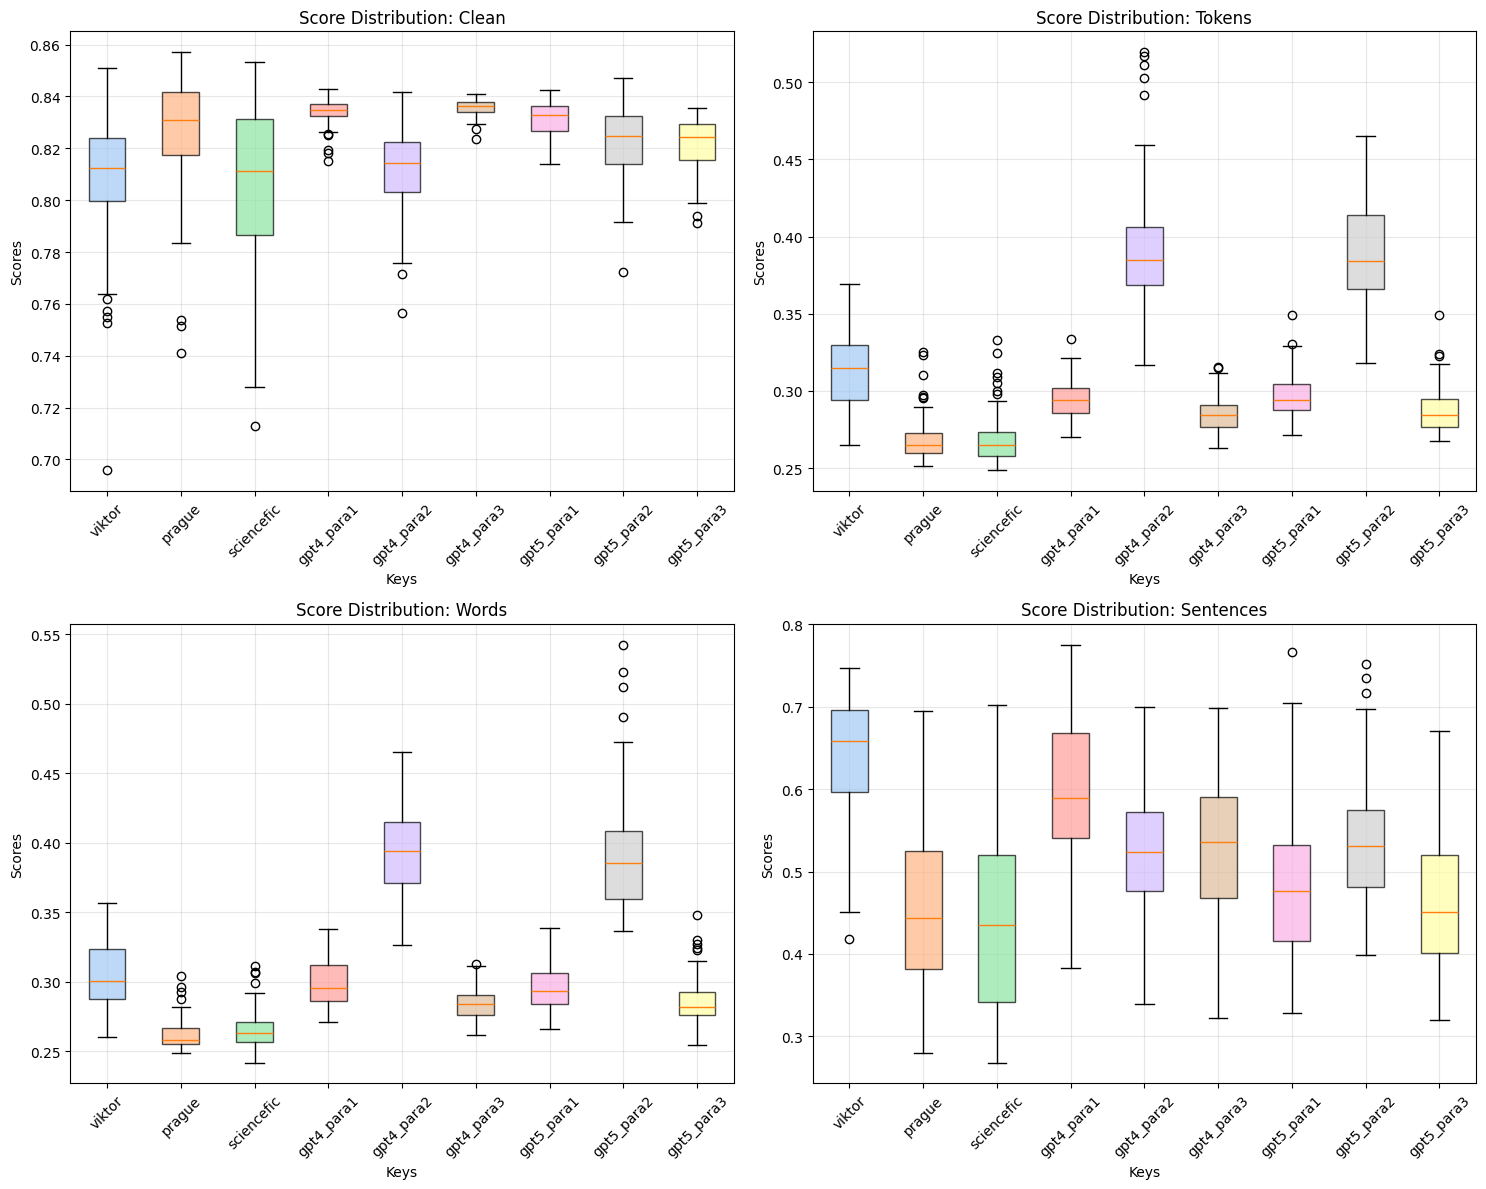

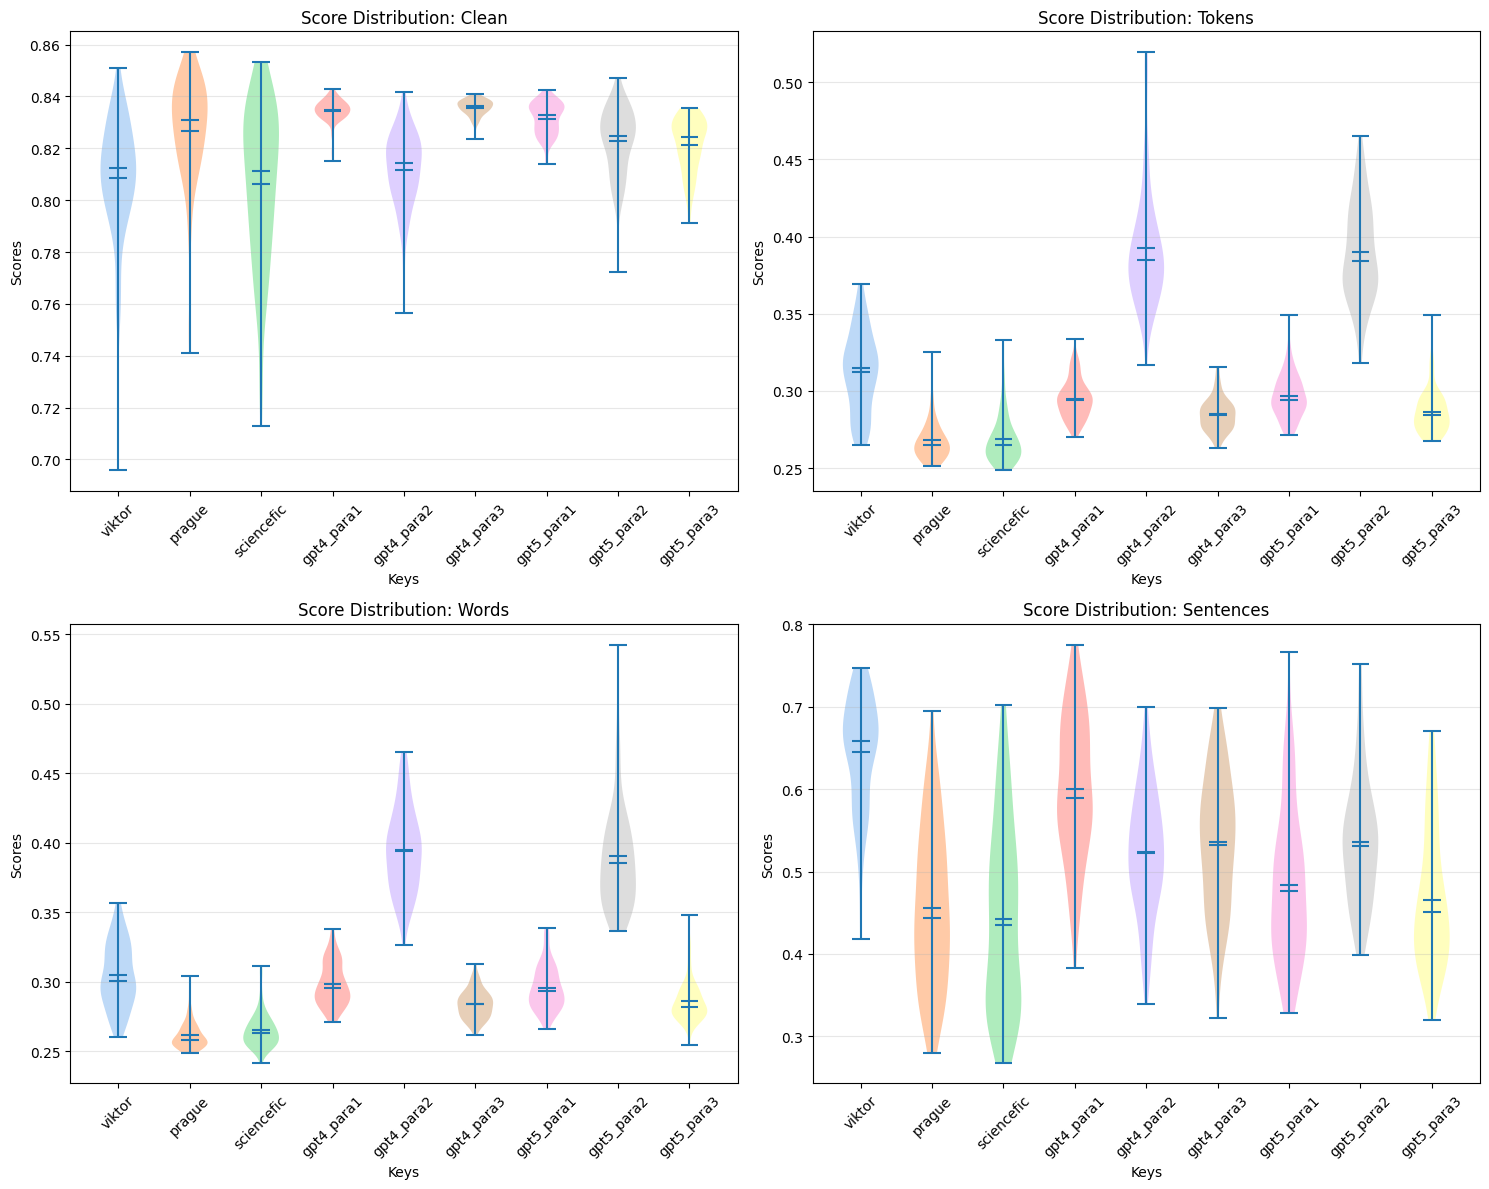

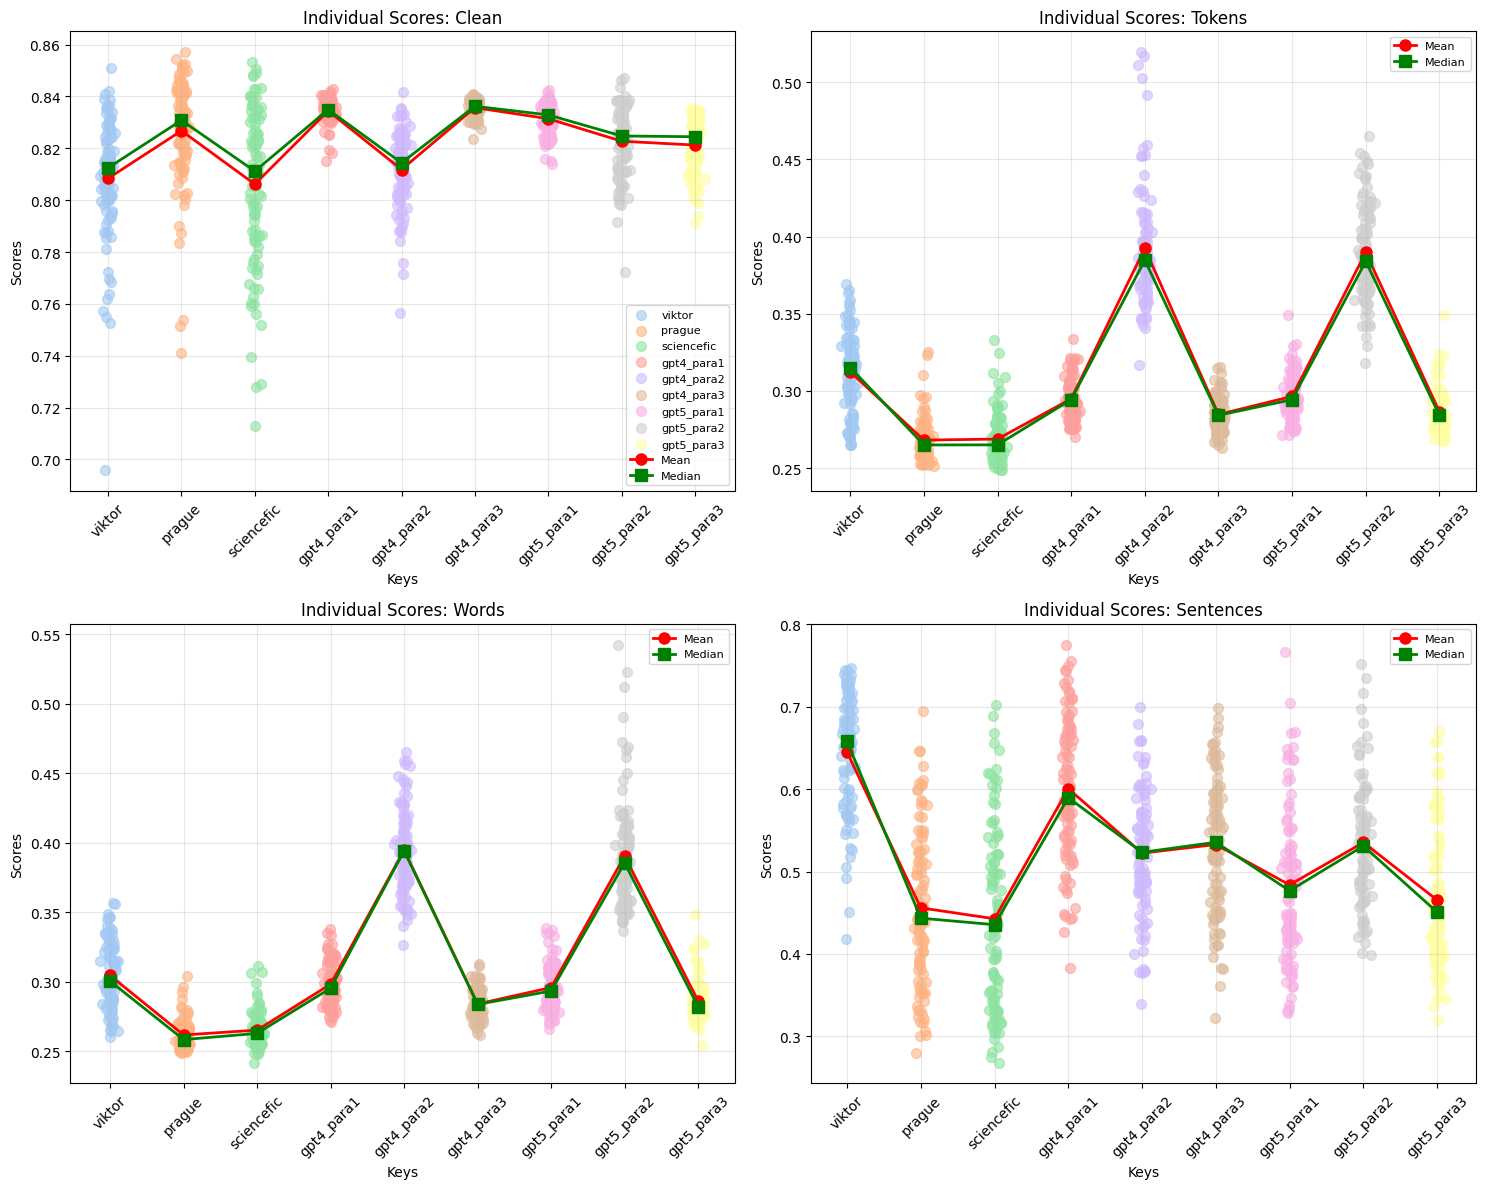

In [171]:
plot_individual_text_types(normalized_results)
plot_violin_individual(normalized_results)
plot_strip_with_stats(normalized_results)

#### CoLA

In [133]:
cola_results = loaded_results["cola"]

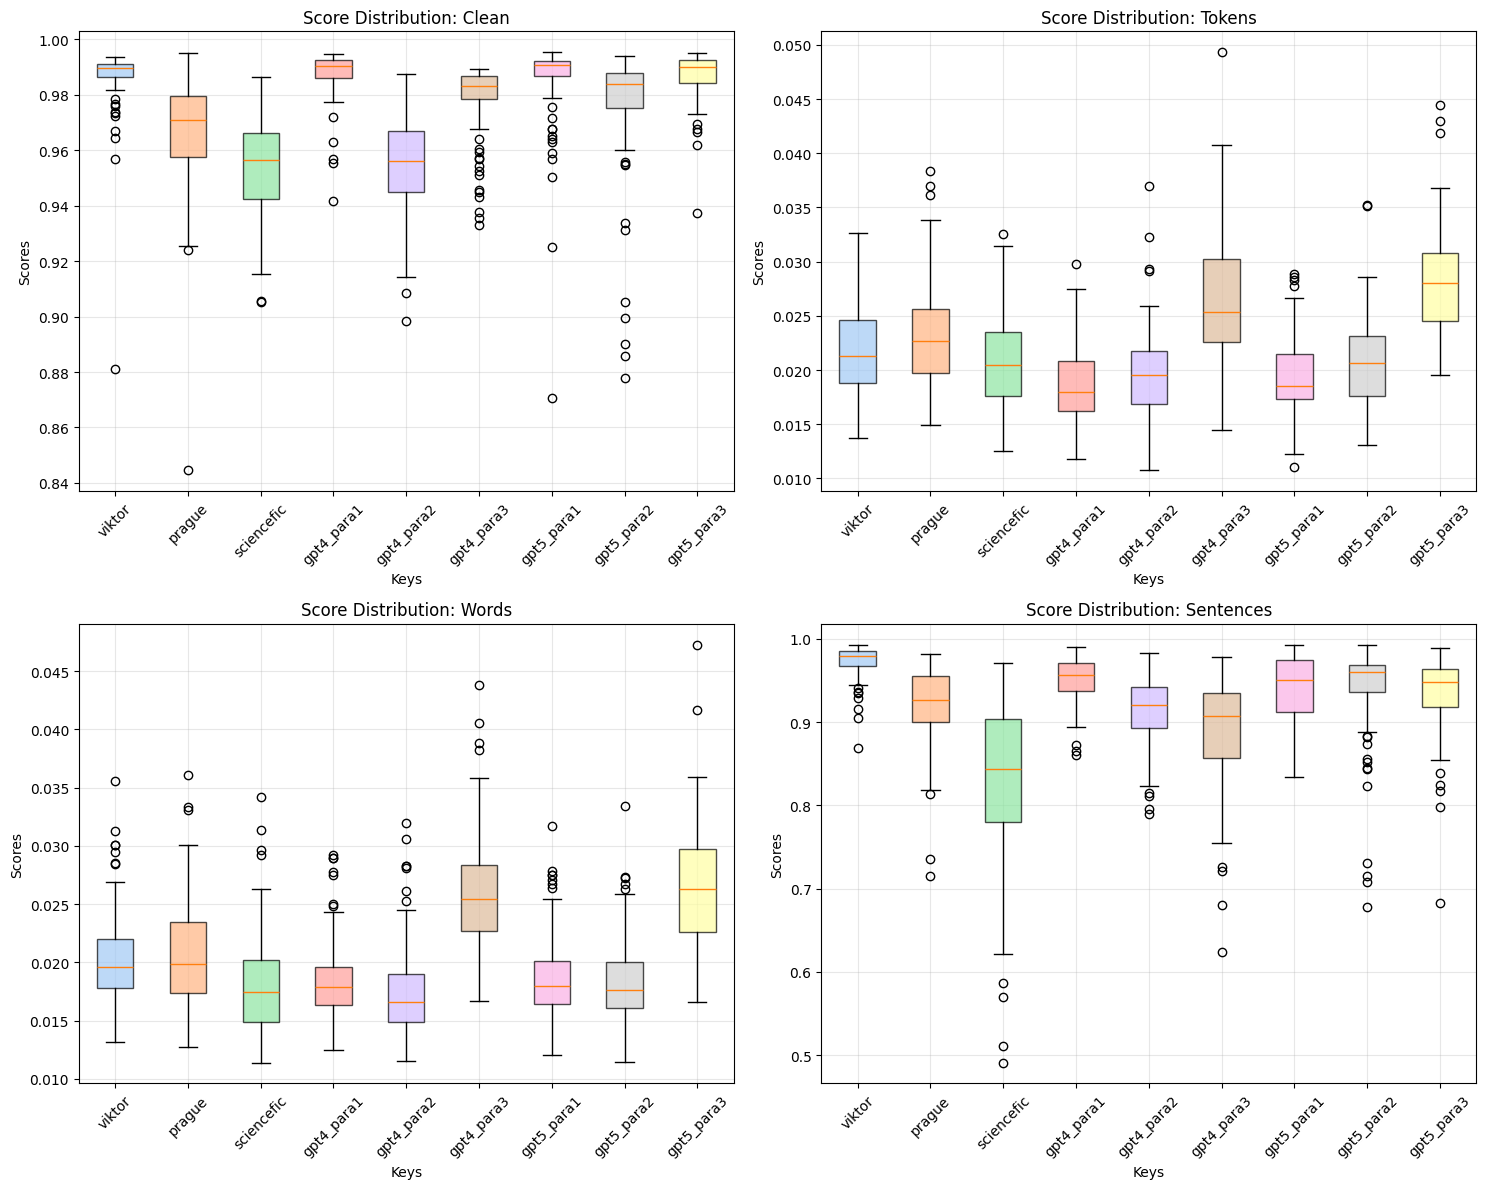

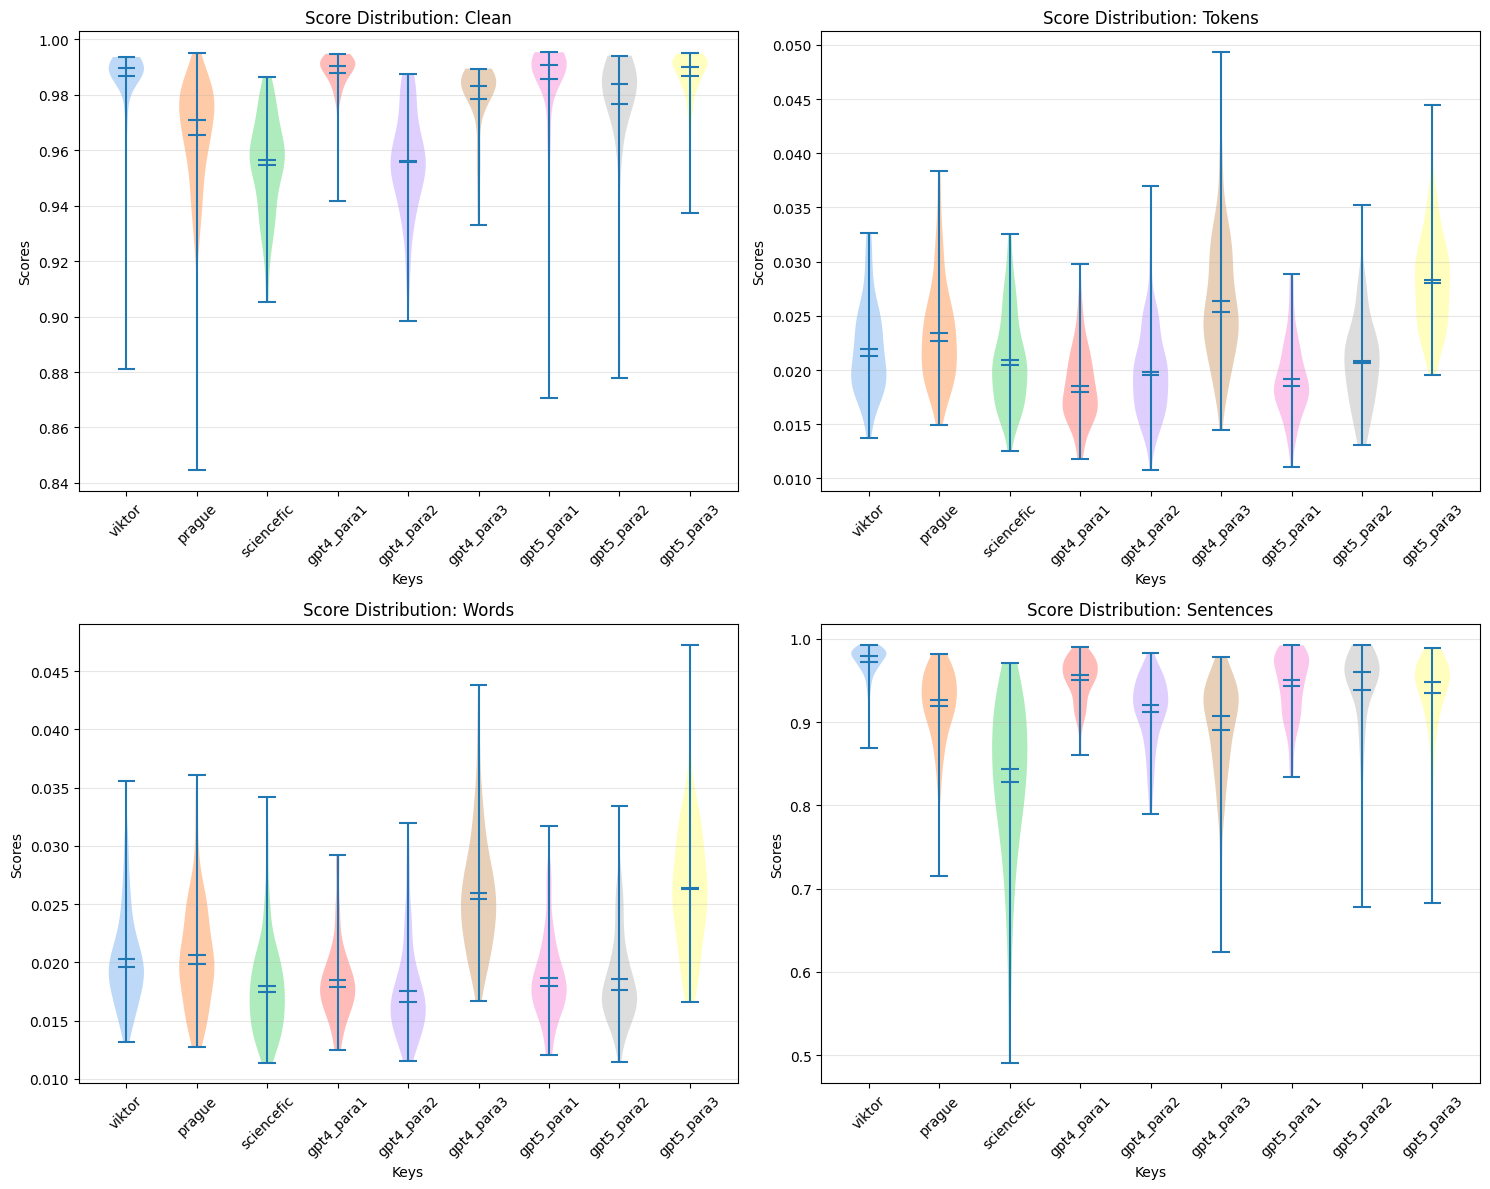

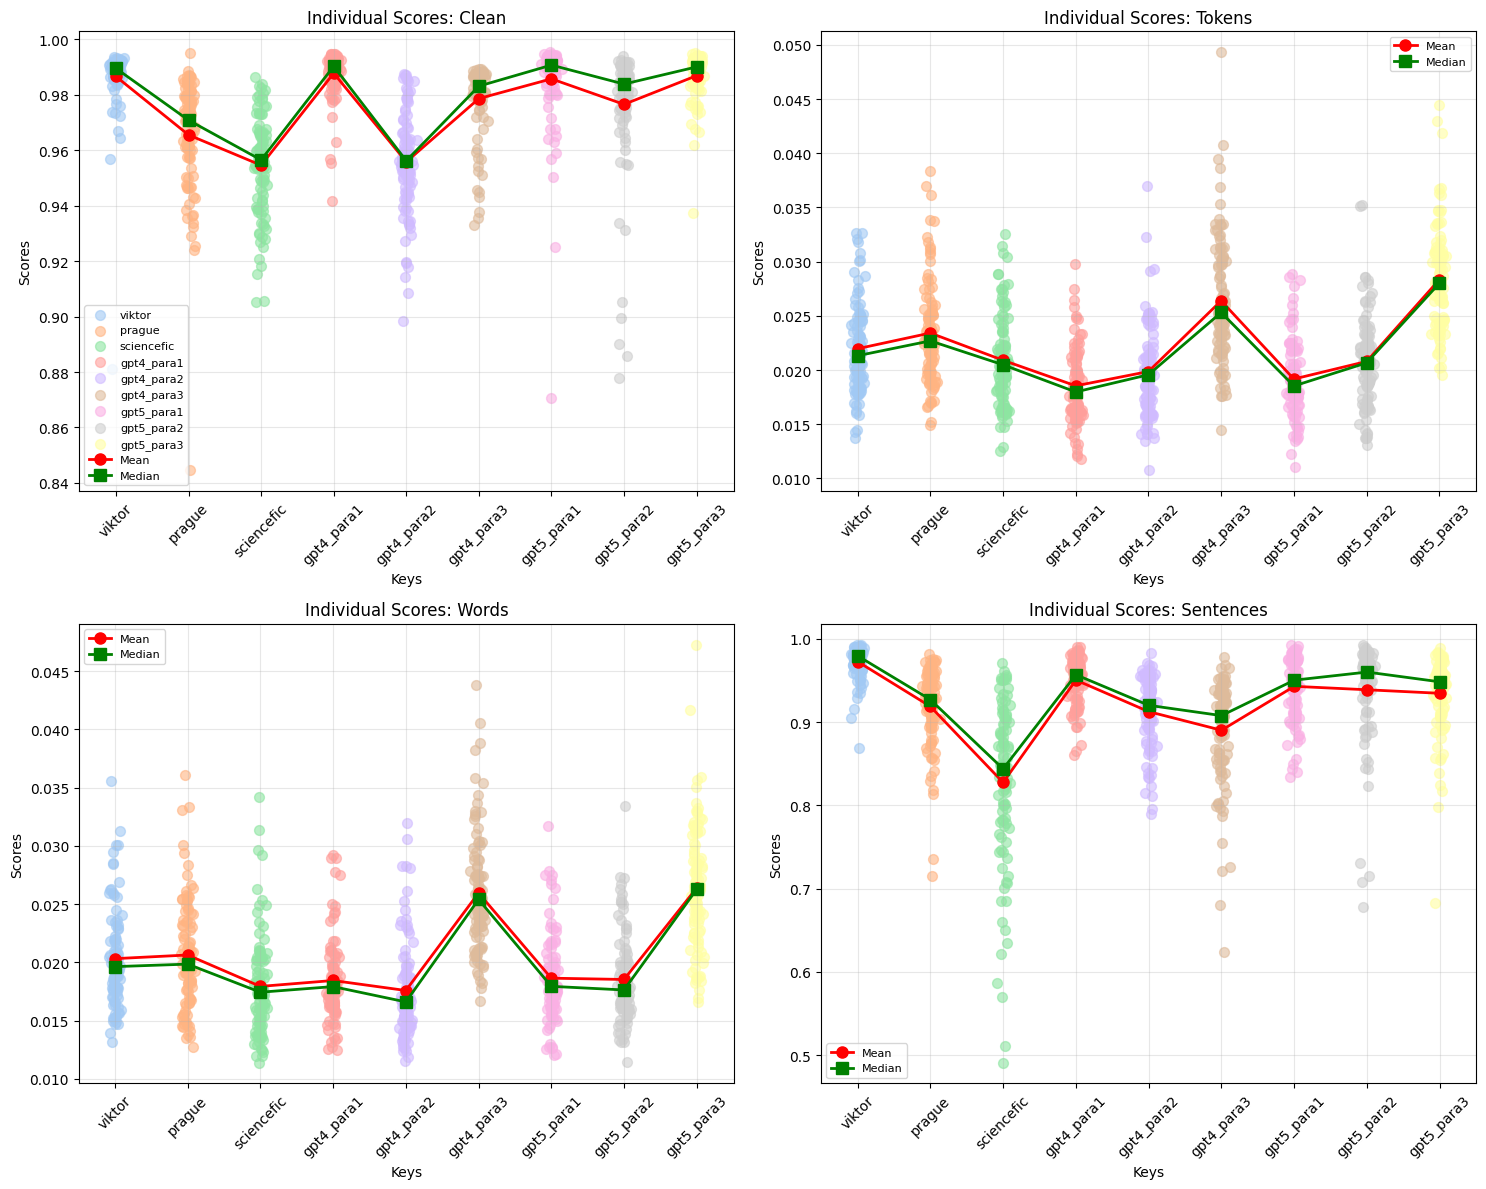

In [172]:
plot_individual_text_types(cola_results)
plot_violin_individual(cola_results)
plot_strip_with_stats(cola_results)

#### Llama

In [184]:
def plot_transition_lines(data):
    """
    Line plot showing mean rating transitions from clean → sentences → words → tokens
    for each story (viktor, prague, etc.)
    """
    # Define the order of transitions
    text_types = ['clean', 'sentences', 'words', 'tokens']
    
    # Filter labels to only those present in data
    active_labels = [label for label in labels if label in data]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X', 'P']
    
    for idx, key in enumerate(active_labels):
        # Calculate mean for each text type
        means = [np.mean(data[key][tt]) for tt in text_types]
        
        # Plot line
        ax.plot(text_types, means, 
                marker=markers[idx], 
                linewidth=2.5, 
                markersize=12,
                label=key, 
                color=color_map[key], 
                alpha=0.85)
        
        # Add value labels on points
        for x, y in zip(range(len(text_types)), means):
            ax.text(x, y + 0.08, f'{y:.2f}', 
                   ha='center', va='bottom', 
                   fontsize=8, 
                   color=color_map[key],
                   fontweight='normal')
    
    ax.set_xlabel('Text Type (Degradation →)', fontsize=13, fontweight='normal')
    ax.set_ylabel('Mean Coherence Score (0-5)', fontsize=13, fontweight='normal')
    ax.set_title('Mean Rating Transitions Across Text Shuffling Types', 
                 fontsize=15, fontweight='normal', pad=20)
    ax.set_ylim(0, 5.5)
    ax.legend(loc='best', framealpha=0.95, fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=2.5, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
    
    plt.tight_layout()
    plt.show()


def plot_transition_with_bands(data):
    """
    Line plot with shaded error bands (standard deviation)
    showing transitions with uncertainty
    """
    text_types = ['clean', 'sentences', 'words', 'tokens']
    
    # Filter labels to only those present in data
    active_labels = [label for label in labels if label in data]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    x_pos = np.arange(len(text_types))
    
    for idx, key in enumerate(active_labels):
        means = [np.mean(data[key][tt]) for tt in text_types]
        stds = [np.std(data[key][tt]) for tt in text_types]
        
        # Plot line
        ax.plot(x_pos, means, 
                marker='o', 
                linewidth=2.5, 
                markersize=10,
                label=key, 
                color=color_map[key], 
                alpha=1)
        
        # Add shaded error band
        ax.fill_between(x_pos, 
                        np.array(means) - np.array(stds),
                        np.array(means) + np.array(stds),
                        alpha=0.15,
                        color=color_map[key])
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(text_types)
    ax.set_xlabel('Text Type (Degradation →)', fontsize=13, fontweight='normal')
    ax.set_ylabel('Mean Coherence Score (0-5)', fontsize=13, fontweight='normal')
    ax.set_title('Mean Rating Transitions with Standard Deviation Bands', 
                 fontsize=15, fontweight='normal', pad=20)
    ax.set_ylim(0, 5.5)
    ax.legend(loc='best', framealpha=0.95, fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()


def plot_transition_heatmap(data):
    """
    Heatmap showing transitions as a matrix
    Rows = stories, Columns = text types
    """
    text_types = ['clean', 'sentences', 'words', 'tokens']
    
    # Filter labels to only those present in data
    active_labels = [label for label in labels if label in data]
    
    # Create matrix in labels order
    matrix = np.zeros((len(active_labels), len(text_types)))
    
    for i, key in enumerate(active_labels):
        for j, tt in enumerate(text_types):
            matrix[i, j] = np.mean(data[key][tt])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=5)
    
    # Set ticks
    ax.set_xticks(np.arange(len(text_types)))
    ax.set_yticks(np.arange(len(active_labels)))
    ax.set_xticklabels(text_types, fontsize=11)
    ax.set_yticklabels(active_labels, fontsize=11)
    
    # Add text annotations
    for i in range(len(active_labels)):
        for j in range(len(text_types)):
            text = ax.text(j, i, f'{matrix[i, j]:.2f}',
                          ha="center", va="center", 
                          color="black", fontsize=11, fontweight='normal')
    
    ax.set_xlabel('Text Type (Degradation →)', fontsize=13, fontweight='normal')
    ax.set_ylabel('Story', fontsize=13, fontweight='normal')
    ax.set_title('Mean Coherence Scores: Transition Heatmap', 
                 fontsize=15, fontweight='normal', pad=20)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean Coherence Score', rotation=270, labelpad=25, fontweight='normal')
    
    plt.tight_layout()
    plt.show()


def plot_transition_slopes(data):
    """
    Focus on the degradation: show slope/drop from clean to tokens
    """
    text_types = ['clean', 'sentences', 'words', 'tokens']
    
    # Filter labels to only those present in data
    active_labels = [label for label in labels if label in data]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, key in enumerate(active_labels):
        means = [np.mean(data[key][tt]) for tt in text_types]
        ax1.plot(text_types, means, 
                marker='o', linewidth=2.5, markersize=10,
                label=key, color=color_map[key], alpha=0.85)
    
    ax1.set_xlabel('Text Type', fontsize=12, fontweight='normal')
    ax1.set_ylabel('Mean Coherence Score (0-5)', fontsize=12, fontweight='normal')
    ax1.set_title('Transitions Across Text Types', fontsize=14, fontweight='normal')
    ax1.legend(loc='best', fontsize=9, ncol=2)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 5.5)
    
    # Right plot: Degradation bars (clean - tokens)
    degradations = []
    bar_colors = []
    for key in active_labels:
        clean_mean = np.mean(data[key]['clean'])
        tokens_mean = np.mean(data[key]['tokens'])
        degradation = clean_mean - tokens_mean
        degradations.append(degradation)
        bar_colors.append(color_map[key])
    
    bars = ax2.bar(active_labels, degradations, color=bar_colors, alpha=0.8, edgecolor='black')
    ax2.set_xlabel('Story', fontsize=12, fontweight='normal')
    ax2.set_ylabel('Score Drop (Clean - Tokens)', fontsize=12, fontweight='normal')
    ax2.set_title('Coherence Degradation: Clean → Tokens', fontsize=14, fontweight='normal')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # Add value labels on bars
    for bar, val in zip(bars, degradations):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom' if val > 0 else 'top',
                fontweight='normal', fontsize=10)
    
    plt.tight_layout()
    plt.show()


def plot_parallel_coordinates(data):
    """
    Parallel coordinates plot showing all transitions
    """
    text_types = ['clean', 'sentences', 'words', 'tokens']
    
    # Filter labels to only those present in data
    active_labels = [label for label in labels if label in data]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create positions for each text type
    positions = np.arange(len(text_types))
    
    for idx, key in enumerate(active_labels):
        means = [np.mean(data[key][tt]) for tt in text_types]
        
        # Draw line connecting all points
        ax.plot(positions, means, 
                marker='o', markersize=14,
                linewidth=3, 
                label=key,
                color=color_map[key],
                alpha=0.9,
                zorder=10)
    
    # Styling
    ax.set_xticks(positions)
    ax.set_xticklabels(text_types, fontsize=12, fontweight='normal')
    ax.set_ylabel('Mean Coherence Score (0-5)', fontsize=13, fontweight='normal')
    ax.set_title('Parallel Coordinates: Coherence Transitions', 
                 fontsize=15, fontweight='normal', pad=20)
    ax.set_ylim(0, 5.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add vertical lines at each axis
    for pos in positions:
        ax.axvline(x=pos, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    
    ax.set_xlim(-0.3, len(text_types) - 0.7)
    ax.legend(loc='best', framealpha=0.95, fontsize=10, ncol=2)
    plt.tight_layout()
    plt.show()

In [185]:
llama_results = loaded_results["llama"]

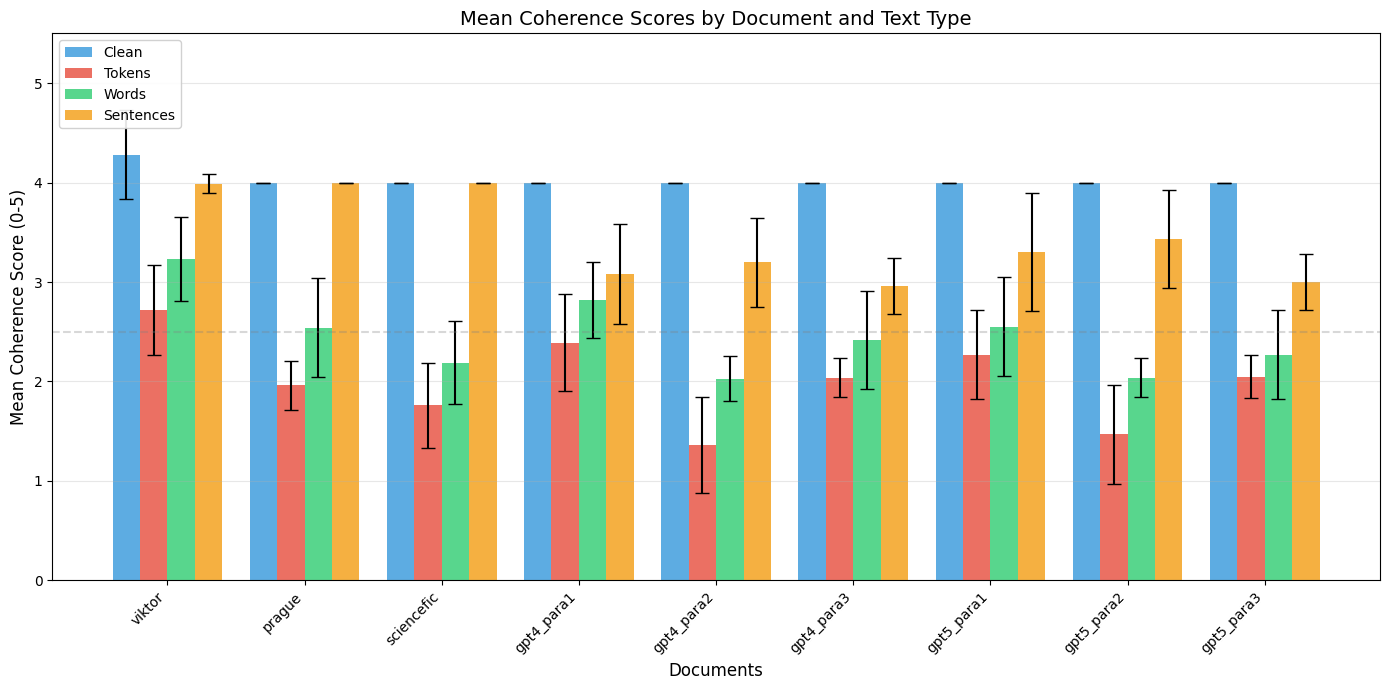

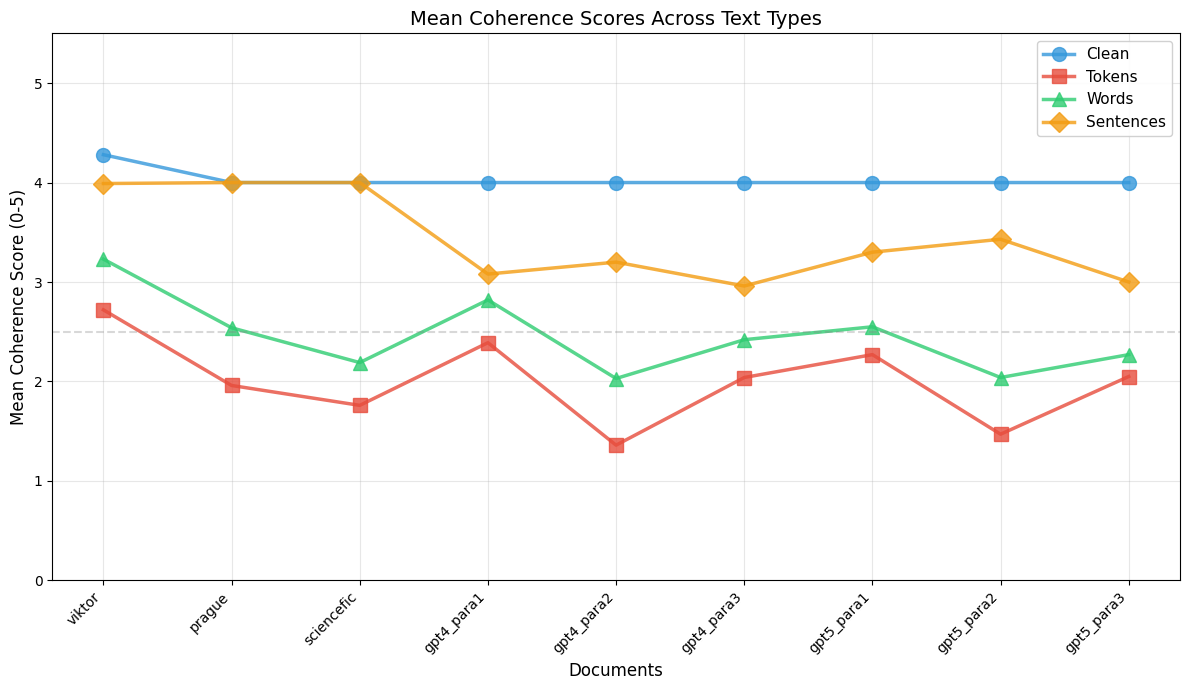

In [195]:
plot_grouped_barplot(llama_results)
plot_comparative_lines(llama_results)

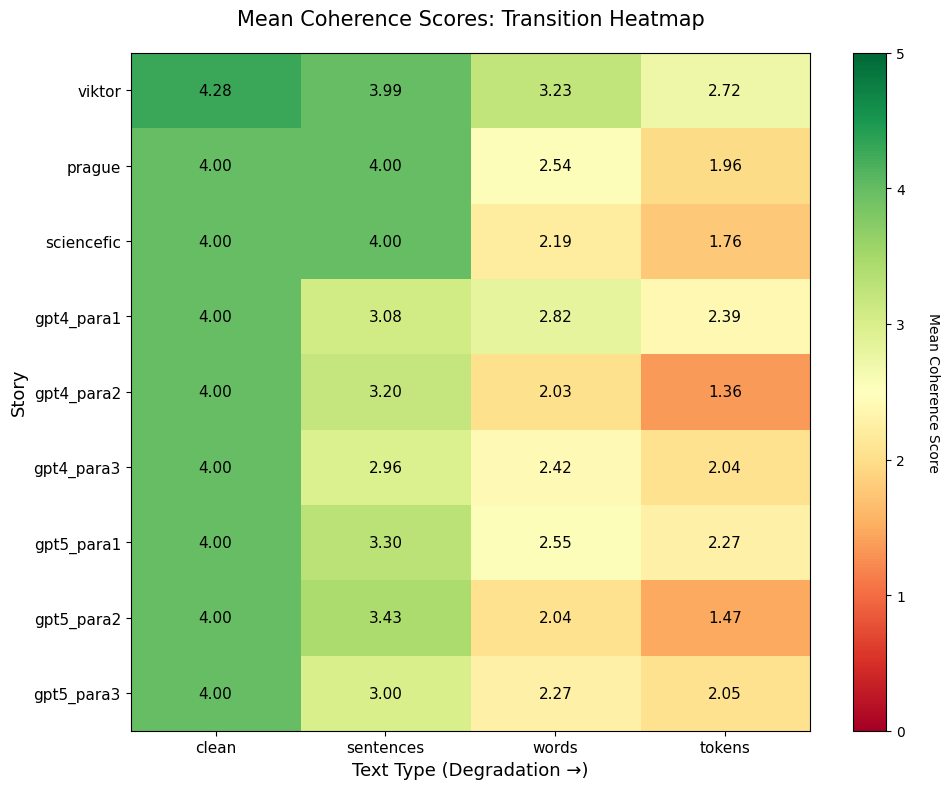

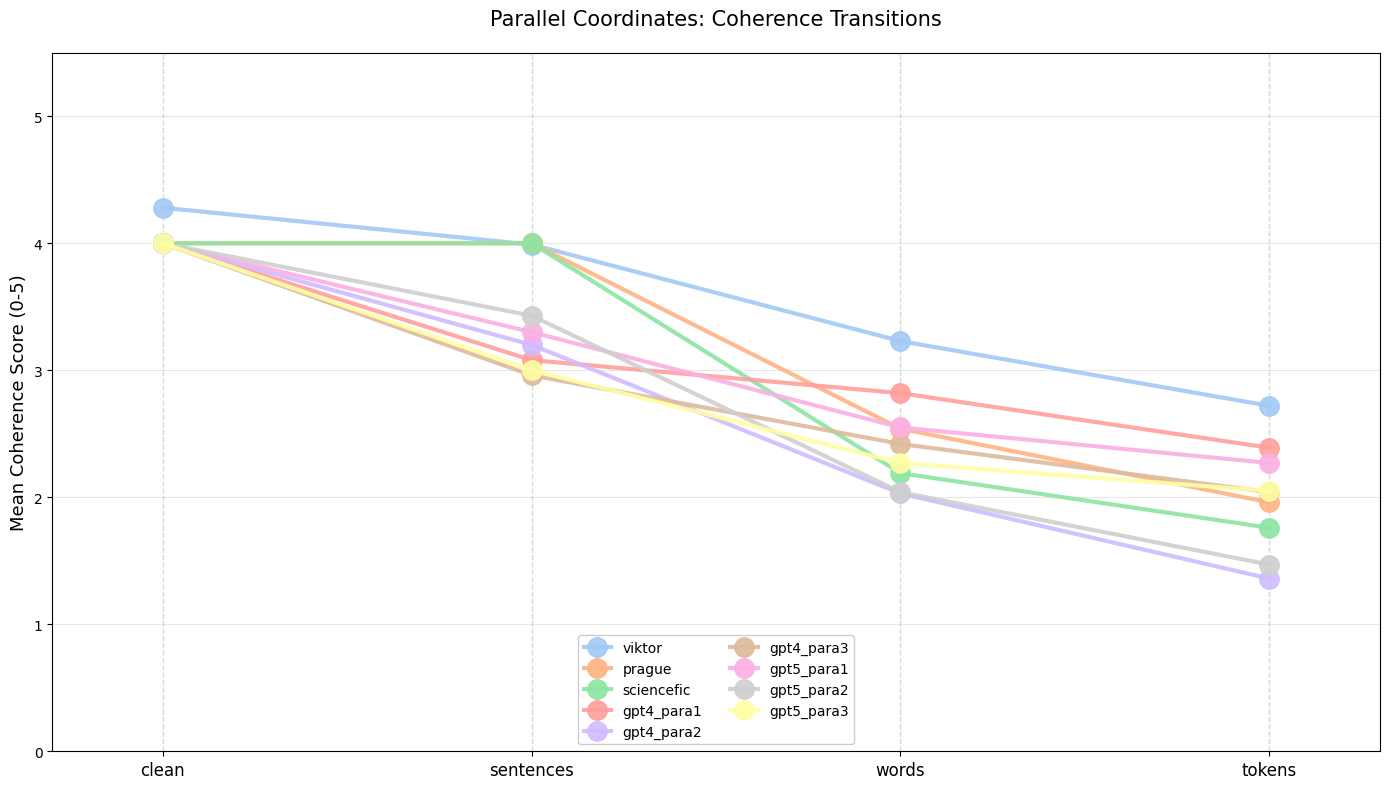

In [187]:
plot_transition_heatmap(llama_results)
plot_parallel_coordinates(llama_results)

In [188]:
prompt_keys = ["viktor", "prague", "sciencefic"]
gpt4 = ["gpt4_para1", "gpt4_para2", "gpt4_para3"]
gpt5 = ["gpt5_para1", "gpt5_para2", "gpt5_para3"]

llama_prompt = {k: llama_results[k] for k in prompt_keys}
llama_gpt4 = {k: llama_results[k] for k in gpt4}
llama_gpt5 = {k: llama_results[k] for k in gpt5}

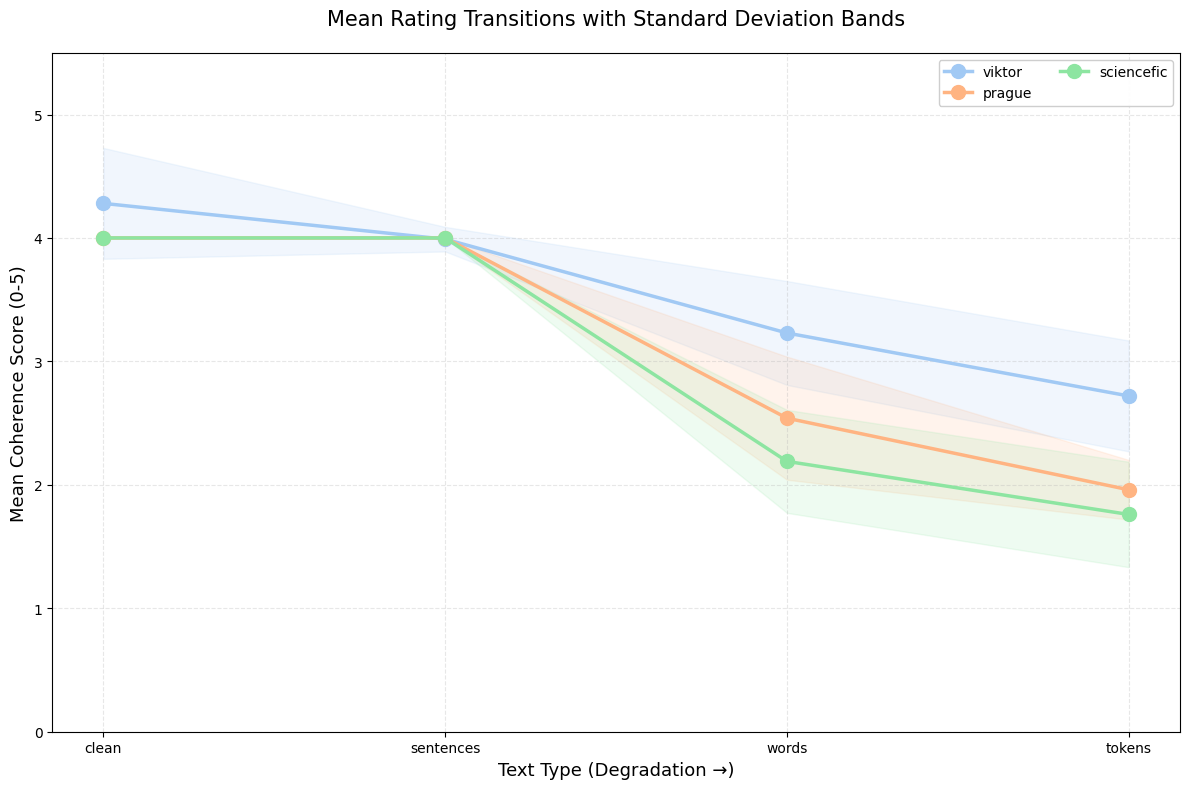

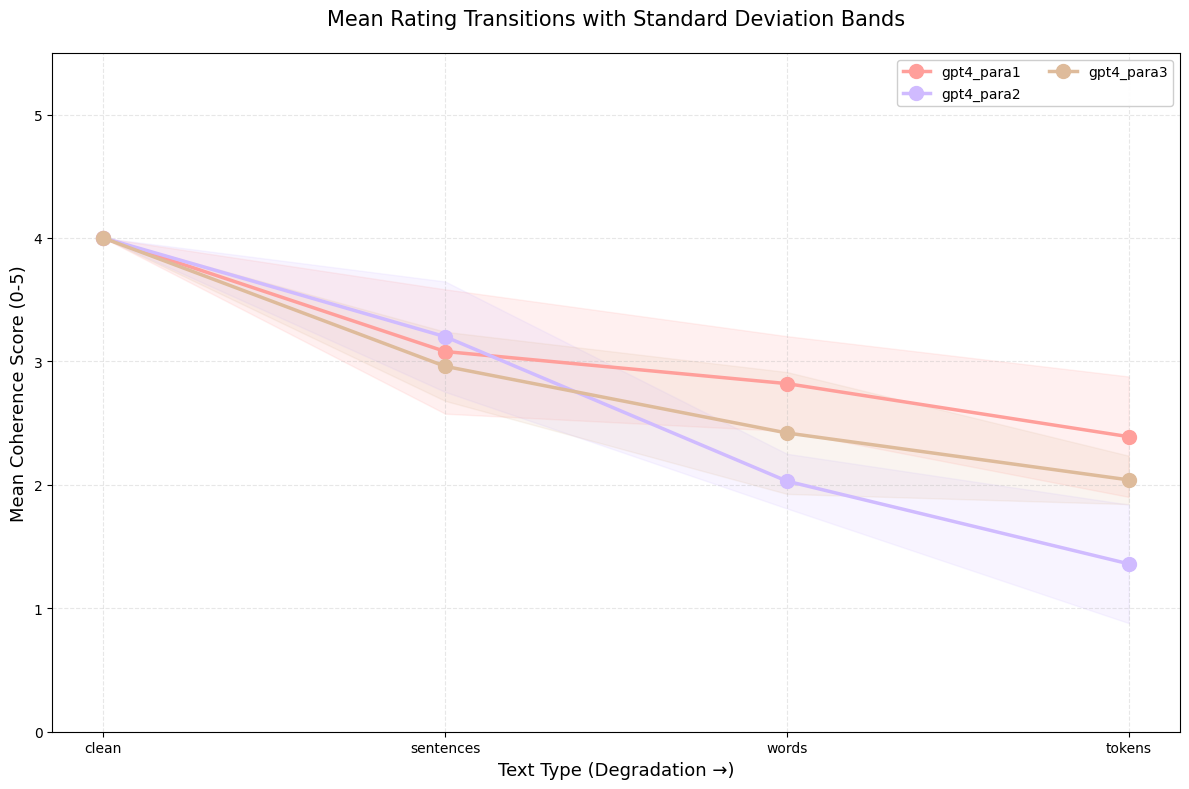

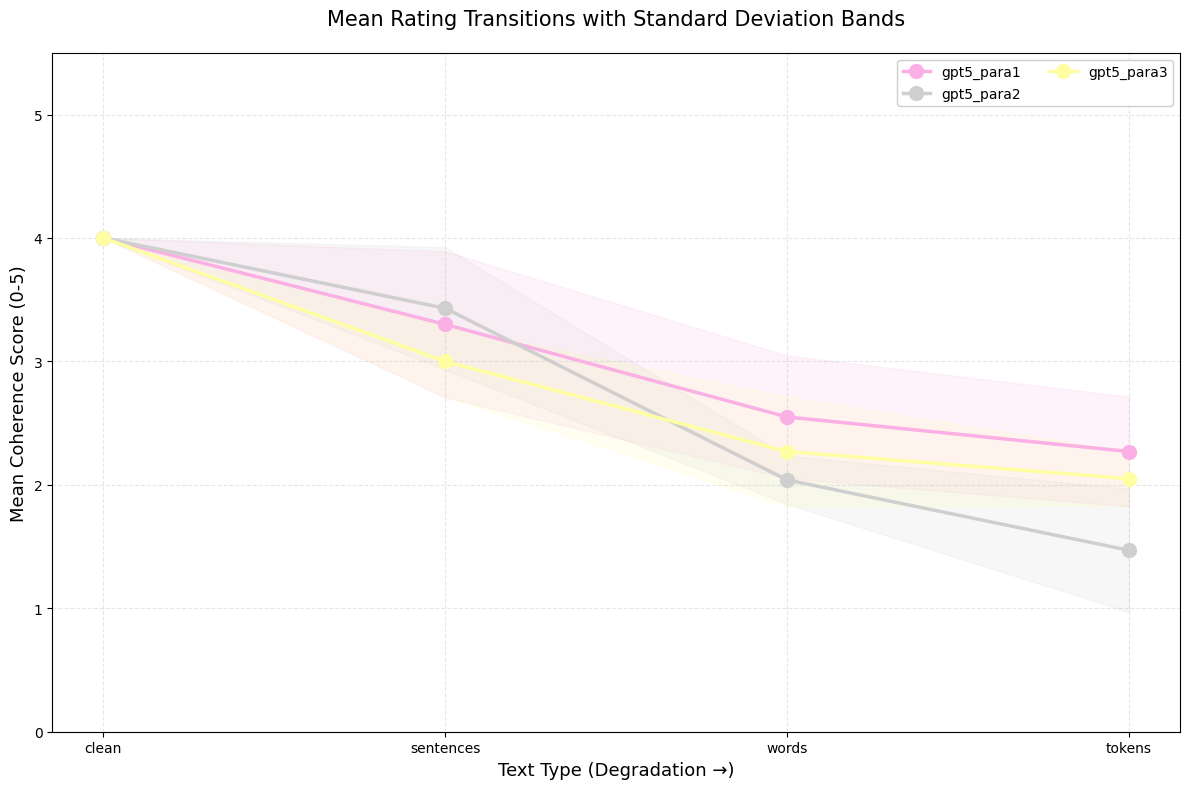

In [189]:
plot_transition_with_bands(llama_prompt)
plot_transition_with_bands(llama_gpt4)
plot_transition_with_bands(llama_gpt5)

#### GPT

In [190]:
gpt_results = loaded_results["gpt"]

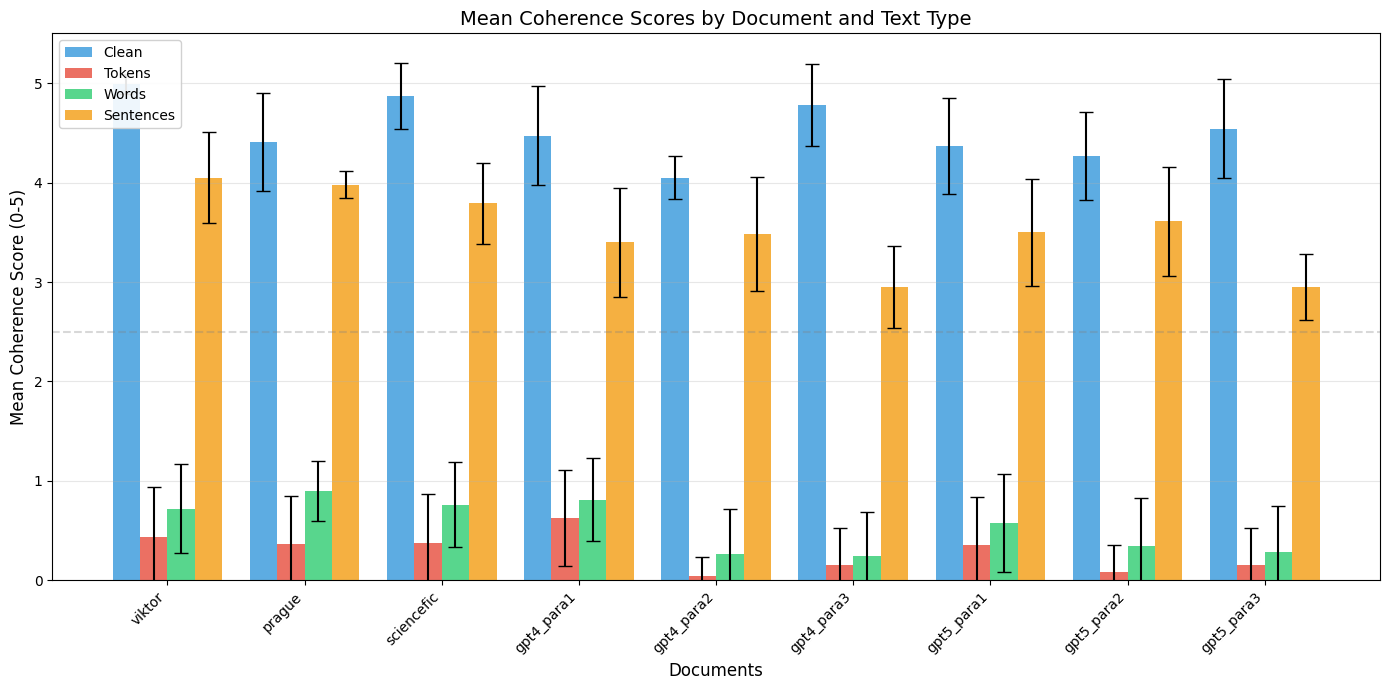

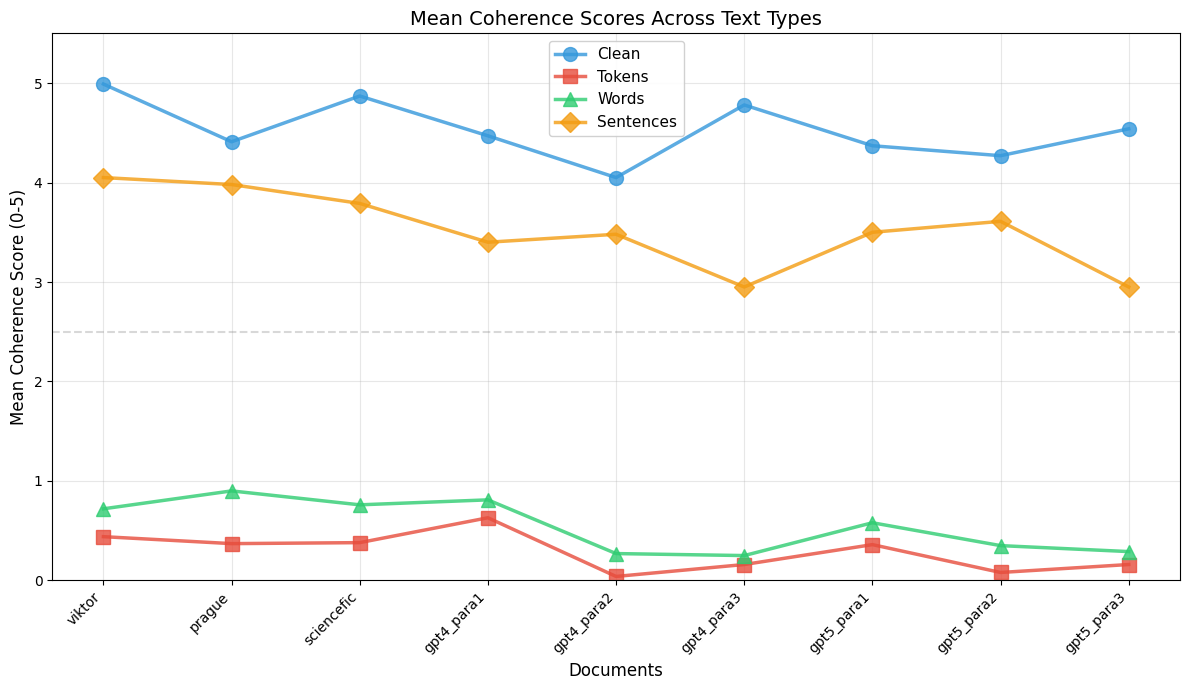

In [196]:
plot_grouped_barplot(gpt_results)
plot_comparative_lines(gpt_results)

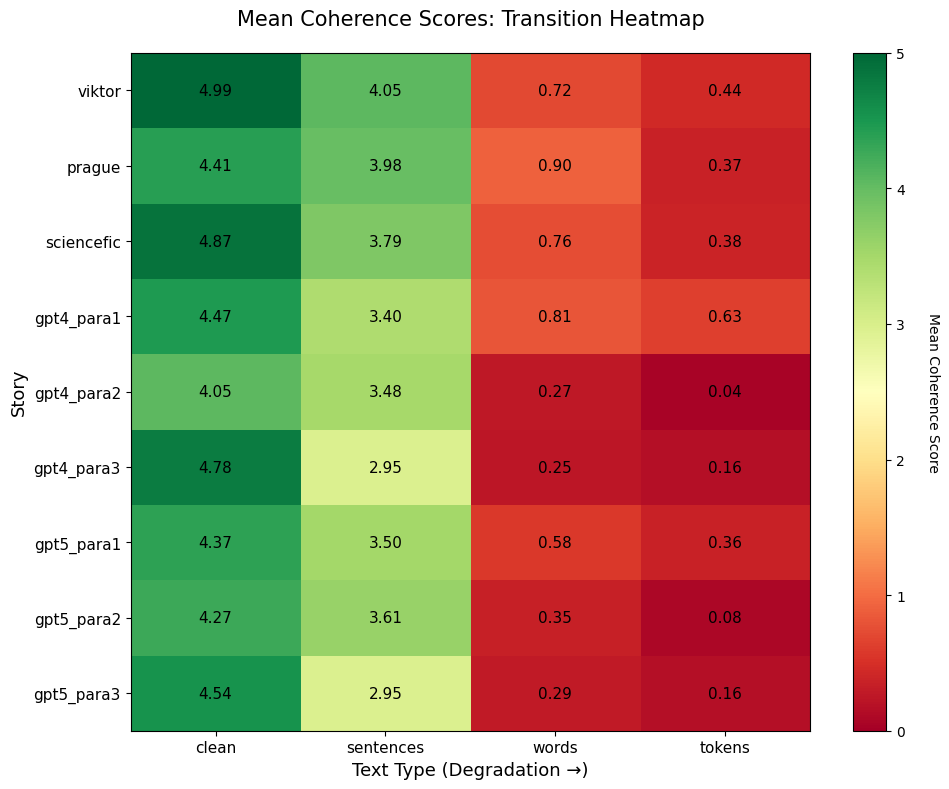

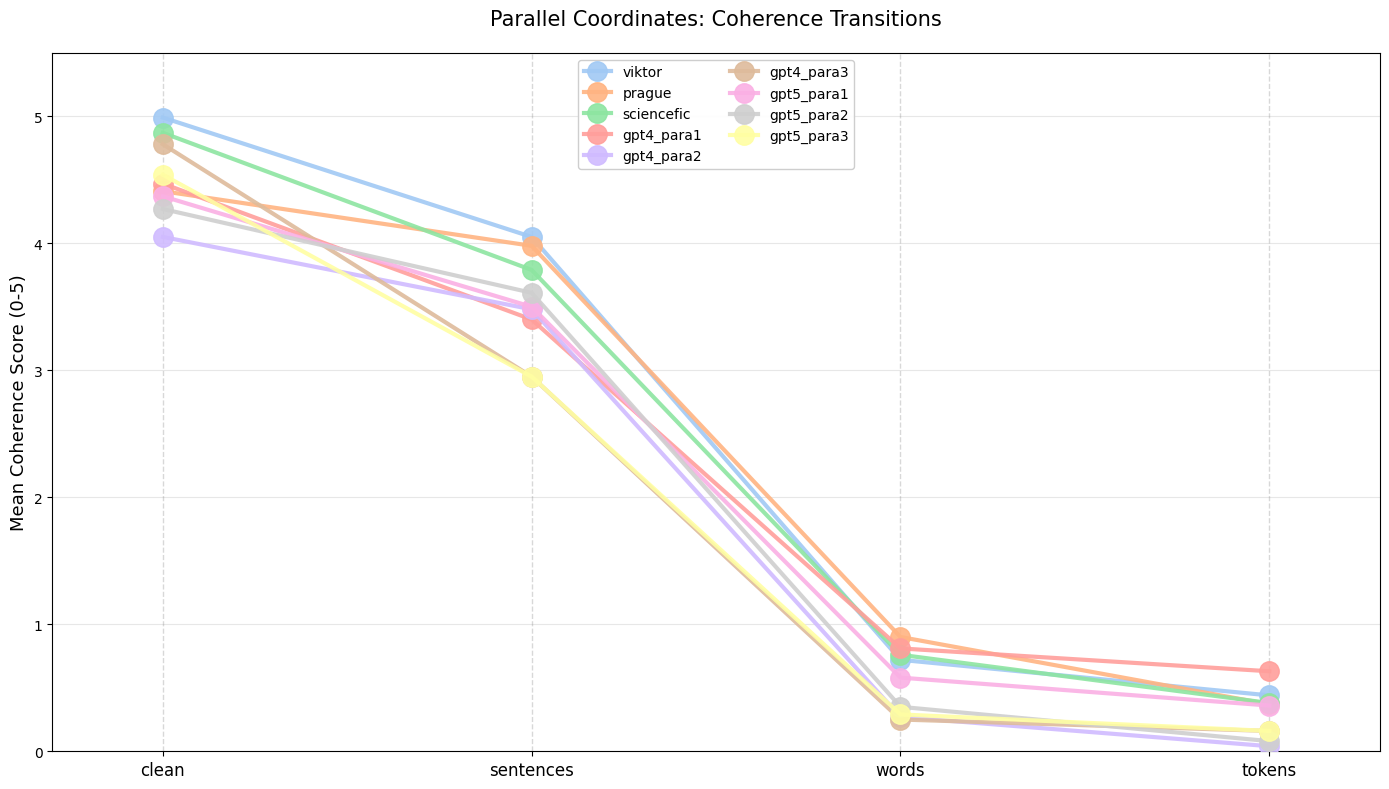

In [192]:
plot_transition_heatmap(gpt_results)
plot_parallel_coordinates(gpt_results)

In [193]:
prompt_keys = ["viktor", "prague", "sciencefic"]
gpt4 = ["gpt4_para1", "gpt4_para2", "gpt4_para3"]
gpt5 = ["gpt5_para1", "gpt5_para2", "gpt5_para3"]

gpt_prompt = {k: gpt_results[k] for k in prompt_keys}
gpt_gpt4 = {k: gpt_results[k] for k in gpt4}
gpt_gpt5 = {k: gpt_results[k] for k in gpt5}

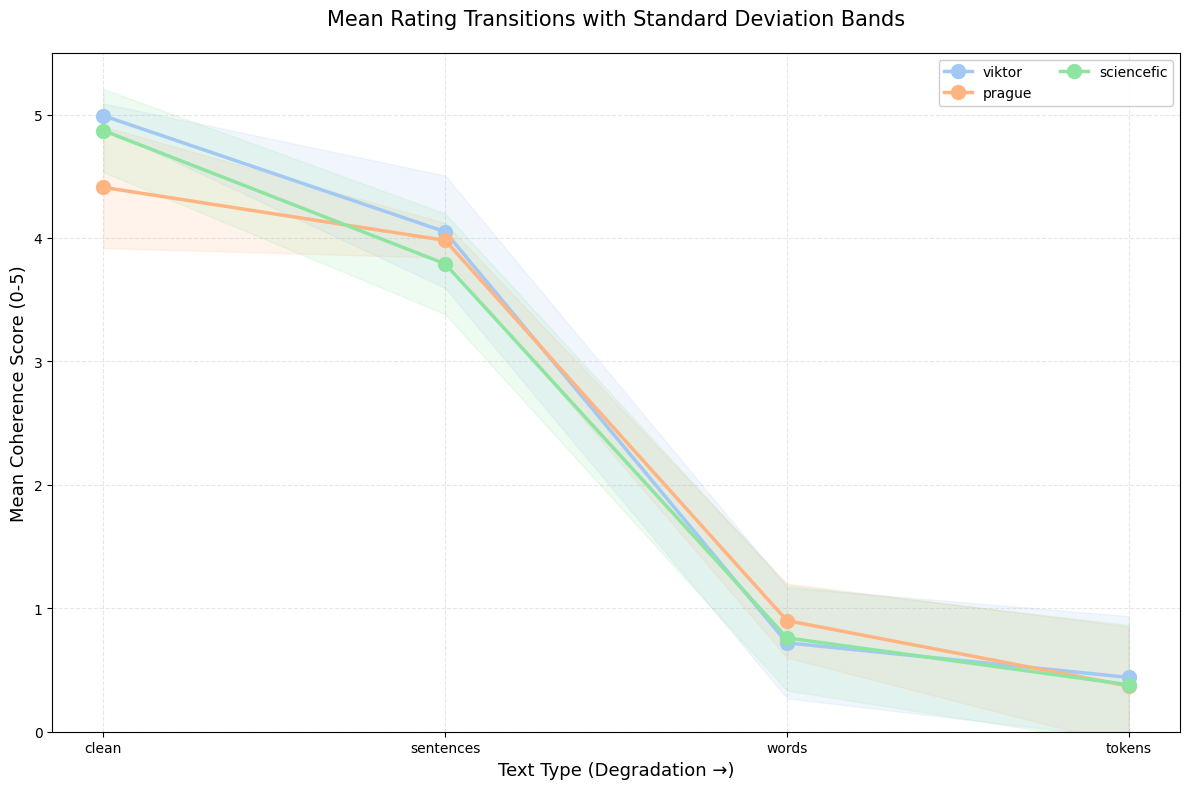

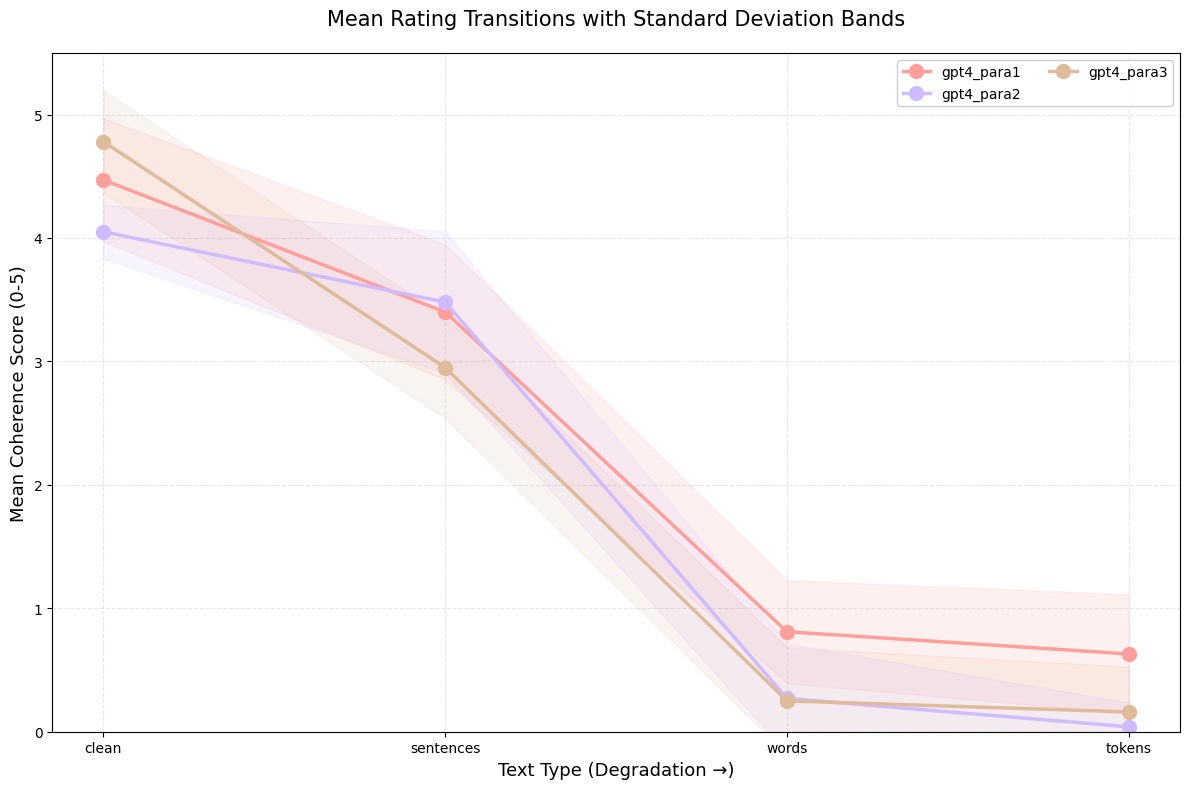

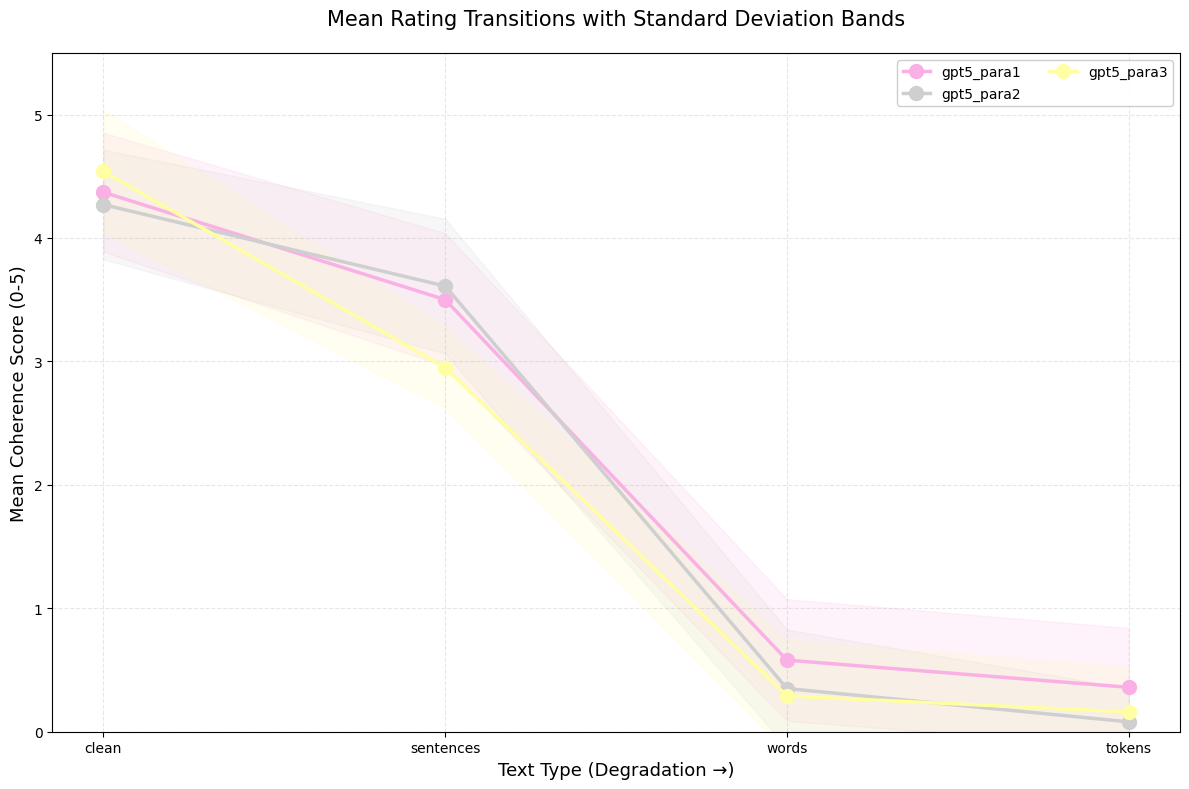

In [194]:
plot_transition_with_bands(gpt_prompt)
plot_transition_with_bands(gpt_gpt4)
plot_transition_with_bands(gpt_gpt5)

### Grouped up plots

In [198]:
def plot_normalized_degradation(data_dict, model_names):
    """
    Plot percentage drop from clean baseline for all models
    data_dict: {'model1': data, 'model2': data, ...}
    model_names: list of model names corresponding to data_dict keys
    """
    text_types = ['clean', 'sentences', 'words', 'tokens']
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors_models = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    markers = ['o', 's', '^', 'D']
    
    for idx, (model_key, model_name) in enumerate(zip(data_dict.keys(), model_names)):
        data = data_dict[model_key]
        
        # Calculate percentage retention (100% = clean baseline)
        all_degradations = []
        
        for key in labels:
            if key in data:
                clean_mean = np.mean(data[key]['clean'])
                degradations = []
                
                for tt in text_types:
                    tt_mean = np.mean(data[key][tt])
                    # Percentage of original score retained
                    pct_retained = (tt_mean / clean_mean) * 100 if clean_mean > 0 else 100
                    degradations.append(pct_retained)
                
                all_degradations.append(degradations)
        
        # Average across all documents
        mean_degradations = np.mean(all_degradations, axis=0)
        std_degradations = np.std(all_degradations, axis=0)
        
        # Plot
        ax.plot(text_types, mean_degradations, 
                marker=markers[idx], 
                linewidth=3, 
                markersize=12,
                label=model_name, 
                color=colors_models[idx], 
                alpha=0.85)
        
        # Add error bars
        ax.fill_between(range(len(text_types)),
                       mean_degradations - std_degradations,
                       mean_degradations + std_degradations,
                       alpha=0.15,
                       color=colors_models[idx])
    
    ax.set_xlabel('Text Type (Degradation →)', fontsize=13, fontweight='normal')
    ax.set_ylabel('Score Retained (% of Clean)', fontsize=13, fontweight='normal')
    ax.set_title('Coherence Score Degradation Across Models', 
                 fontsize=15, fontweight='normal', pad=20)
    ax.set_ylim(0, 105)
    ax.legend(loc='best', framealpha=0.95, fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=100, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Baseline (Clean)')
    
    plt.tight_layout()
    plt.show()

In [205]:
loaded_results["the_coherence"] = normalize_with_sigmoid(loaded_results["the_coherence"], temperature=1.0)

Data statistics:
  Mean: -10.5222
  Std: 17.6514
  Min: -30.7012
  Max: 21.0903


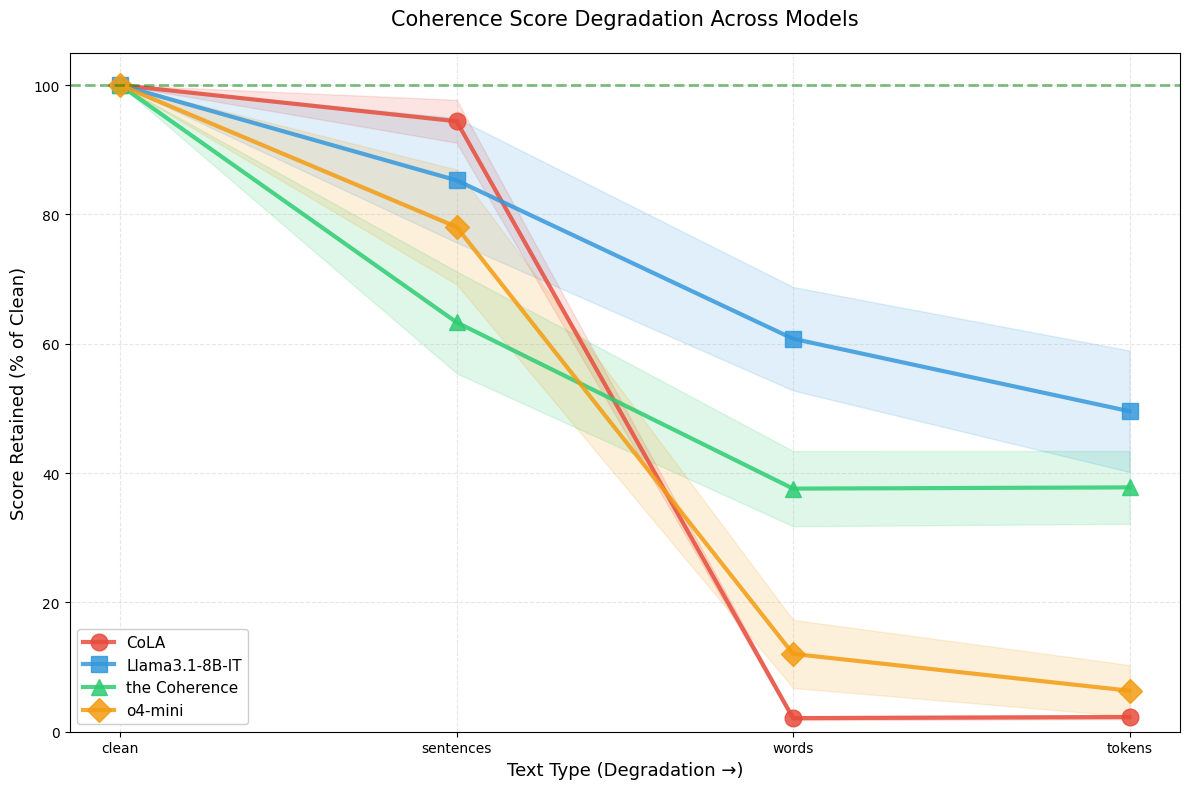

In [206]:
plot_normalized_degradation(loaded_results, ["CoLA", "Llama3.1-8B-IT", "the Coherence", "o4-mini"])

In [207]:
def plot_zscore_degradation(data_dict, model_names):
    """
    Plot using z-score normalization
    """
    text_types = ['clean', 'sentences', 'words', 'tokens']
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    markers = ['o', 's', '^', 'D']
    
    for idx, (model_key, model_name) in enumerate(zip(data_dict.keys(), model_names)):
        data = data_dict[model_key]
        
        # Collect all scores for this model
        all_scores = []
        for key in labels:
            if key in data:
                for tt in text_types:
                    all_scores.extend(data[key][tt])
        
        mean_all = np.mean(all_scores)
        std_all = np.std(all_scores)
        
        # Calculate z-scores for each text type
        zscores = []
        for tt in text_types:
            tt_scores = []
            for key in labels:
                if key in data:
                    tt_scores.extend(data[key][tt])
            
            zscore = (np.mean(tt_scores) - mean_all) / std_all
            zscores.append(zscore)
        
        ax.plot(text_types, zscores, 
                marker=markers[idx], 
                linewidth=3, 
                markersize=12,
                label=model_name, 
                color=colors[idx], 
                alpha=0.85)
    
    ax.set_xlabel('Text Type (Degradation →)', fontsize=13, fontweight='normal')
    ax.set_ylabel('Z-Score (Standard Deviations from Mean)', fontsize=13, fontweight='normal')
    ax.set_title('Normalized Coherence Degradation (Z-Scores)', 
                 fontsize=15, fontweight='normal', pad=20)
    ax.legend(loc='best', framealpha=0.95, fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.show()

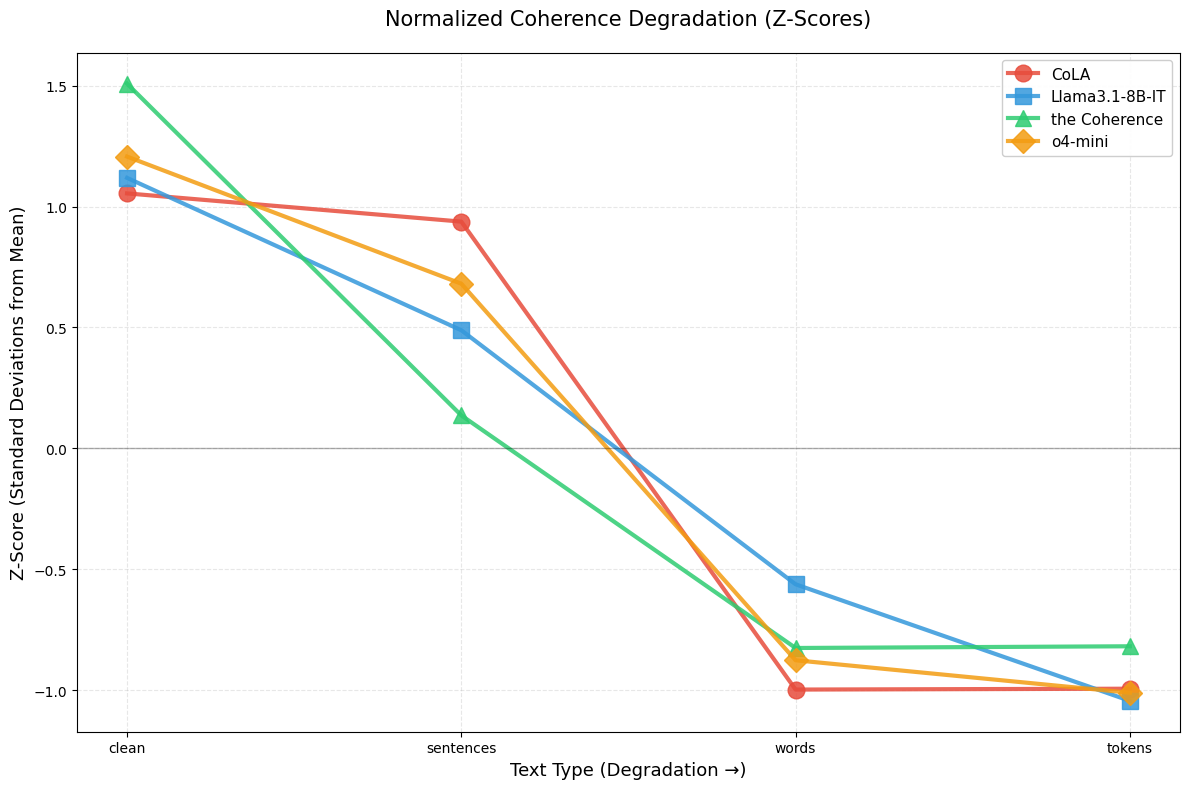

In [208]:
plot_zscore_degradation(loaded_results, ["CoLA", "Llama3.1-8B-IT", "the Coherence", "o4-mini"])